# 02 — PPI, Radar Moments, Beam Geometry and Doppler QC
## DRRAA Omkoi S-band Weather Radar

**Teaching case**

- Site: **Omkoi**
- Radar: **S-band**
- Radar altitude: **1,173 m MSL**
- Observation period: **18 March 2023, 18:00–18:54 UTC**
- Thailand local time: **19 March 2023, 01:00–01:54 ICT**
- Temporal resolution: **6 min**
- Volume scan: **14 elevation angles, 0.5°–19.5°**
- Gate spacing: **500 m**
- Maximum range: approximately **237 km**
- Nyquist velocity: approximately **16.7 m s⁻¹**

Notebook 01 validated the source dataset. Notebook 02 develops the first scientific radar-analysis workflow:

```text
PPI geometry
    ↓
Beam height + polar sampling
    ↓
Raw ZH → corrected ZH → common-mask diagnostics
    ↓
Radial velocity → Nyquist → folding → dealiasing
    ↓
Spectrum width
    ↓
Multi-elevation structure
    ↓
Geographic PPI + GIS
    ↓
One-hour evolution
```

> **Core principles**
>
> `PPI ≠ CAPPI`
>
> `Radial velocity ≠ full wind speed`
>
> `Corrected reflectivity ≠ ground truth`
>
> `Dealiased velocity ≠ automatically correct everywhere`
>
> `High spectrum width ≠ confirmed turbulence`

# Learning outcomes

เมื่อจบ Notebook 02 ผู้เรียนควรสามารถ:

1. อธิบาย PPI เป็น conical radar scan
2. คำนวณ approximate beam-center height ด้วย 4/3-Earth model
3. แยก along-beam gate spacing ออกจาก cross-beam sampling
4. plot raw และ corrected reflectivity ด้วยมาตรฐานเดียวกัน
5. เปรียบเทียบ reflectivity ด้วย common valid mask
6. อธิบาย radial Doppler velocity และ Nyquist interval
7. ตรวจ candidate folding และทำ region-based dealiasing
8. ประเมินพื้นที่ที่ dealiasing เปลี่ยนข้อมูล
9. อธิบาย spectrum width และข้อจำกัด
10. เปรียบเทียบหลาย elevation angles โดยไม่เรียกว่า vertical cross-section
11. สร้าง geographic PPI พร้อม ADM1/ADM2
12. สร้าง one-hour radar evolution จาก 10 volumes
13. ประเมิน dual-pol availability ภายใน strong echoes
14. export figure + metadata เพื่อ reproducibility

**CORE** — ป.ตรี ปี 3–4  
**ADVANCED** — ป.โท  
**EXPERIMENT** — ปรับ parameter แล้วอธิบายผล  
**RESEARCH NOTE** — ข้อควรระวังก่อนใช้ในงานตีพิมพ์

# 1. Install the teaching environment

In [1]:
# CELL 1 — Install / check packages
import sys, subprocess
PACKAGE_SPECS = [
    'arm-pyart==2.2.5',
    'geopandas>=1.0',
    'pyogrio>=0.10',
    'cartopy>=0.23',
    'pyproj>=3.6',
    'shapely>=2.0',
    'pandas>=2.0',
    'matplotlib>=3.8',
    'netCDF4>=1.6',
]
subprocess.check_call([
    sys.executable, '-m', 'pip', 'install', '-q',
    '--upgrade-strategy', 'only-if-needed', *PACKAGE_SPECS
])
print('Notebook 02 environment ready.')

Notebook 02 environment ready.


# 2. Mount Google Drive

In [2]:
# CELL 2 — Mount Drive
from pathlib import Path
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE_ROOT = Path('/content/drive/MyDrive')
except ImportError:
    DRIVE_ROOT = Path.cwd()
    print('google.colab not detected; using:', DRIVE_ROOT)

Mounted at /content/drive


# 3. Imports, versions and publication defaults

In [3]:
# CELL 3 — Imports and versions
from __future__ import annotations
import gzip, json, shutil, sys, tempfile, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
import cartopy
import cartopy.crs as ccrs
import pyproj
from pyproj import Geod
import pyart
from netCDF4 import num2date
from IPython.display import display
warnings.filterwarnings('ignore', category=UserWarning)
SOFTWARE_VERSIONS = {
    'python': sys.version.split()[0],
    'numpy': np.__version__, 'pandas': pd.__version__,
    'matplotlib': matplotlib.__version__, 'pyart': pyart.__version__,
    'geopandas': gpd.__version__, 'cartopy': cartopy.__version__,
    'pyproj': pyproj.__version__,
}
display(pd.DataFrame(SOFTWARE_VERSIONS.items(), columns=['software','version']))

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 8.5,
    'axes.linewidth': 0.8,
    'lines.linewidth': 1.2,
    'figure.constrained_layout.use': True,
})


## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly supported
## by the U.S. Department of Energy Office of Science as part of
## the Atmospheric Radiation Measurement (ARM) User Facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119



,software,version
0,python,3.13.15
1,numpy,2.1.3
2,pandas,2.2.3
3,matplotlib,3.10.0
4,pyart,2.2.5
5,geopandas,1.1.4
6,cartopy,0.25.0
7,pyproj,3.7.2


# 4. Load Notebook 01 workspace and readiness

In [4]:
# CELL 4 — Load course config / status
COURSE_NAME = 'Teaching_DRRAA_WeatherRadar_GIS'
ROOT = DRIVE_ROOT / COURSE_NAME
CONFIG_JSON = ROOT / '00_config' / 'course_config.json'
STATUS_JSON = ROOT / '99_logs' / '01_setup_status.json'
if not CONFIG_JSON.exists() or not STATUS_JSON.exists():
    raise FileNotFoundError('Notebook 01 outputs are missing. Run Notebook 01 first.')
with CONFIG_JSON.open('r', encoding='utf-8') as f:
    COURSE_CONFIG = json.load(f)
with STATUS_JSON.open('r', encoding='utf-8') as f:
    SETUP_STATUS = json.load(f)
if not SETUP_STATUS.get('ready', False):
    raise RuntimeError('Notebook 01 dataset readiness is not PASS.')
print('Notebook 01 readiness: PASS')
print('Dataset:', COURSE_CONFIG.get('dataset_label'))
print('Radar site:', COURSE_CONFIG['radar'].get('site_name'))
print('Radar band:', COURSE_CONFIG['radar'].get('band'))

Notebook 01 readiness: PASS
Dataset: DRRAA_Sband_20230318_one_hour_v1
Radar site: Omkoi
Radar band: S


In [5]:
# CELL 5 — Paths
WORKSPACE = COURSE_CONFIG['workspace']
RADAR_DIR = Path(WORKSPACE['radar'])
GIS_CANONICAL_DIR = Path(WORKSPACE['gis_canonical'])
METADATA_DIR = Path(WORKSPACE['metadata'])
OUTPUT_CSV_DIR = Path(WORKSPACE['output_csv'])
FIGURE_DIR = ROOT / '04_figures' / '02'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_CSV_DIR.mkdir(parents=True, exist_ok=True)
GIS_GPKG = GIS_CANONICAL_DIR / 'thailand_admin_boundaries.gpkg'
RADAR_FILES = COURSE_CONFIG['radar']['source_files']
print('Radar:', RADAR_DIR)
print('GIS:', GIS_GPKG)
print('Figures:', FIGURE_DIR)

Radar: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/01_data/radar
GIS: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/01_data/gis/canonical/thailand_admin_boundaries.gpkg
Figures: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02


# 5. Parameter block

In [6]:
# CELL 6 — Teaching parameters
RADAR_INDEX = 0
SWEEP = 0
FIELD_Z_RAW = 'reflectivity'
FIELD_Z_CORR = 'corrected_reflectivity'
FIELD_VEL = 'velocity'
FIELD_SW = 'spectrum_width'
FIELD_VEL_DEALIASED = 'velocity_dealiased'
PLOT_RANGE_KM = 200.0
Z_MIN, Z_MAX = -10.0, 70.0
DELTA_Z_LIMIT = 20.0
DEALIAS_Z_MIN_DBZ = 5.0
SW_Z_MIN_DBZ = 10.0
ZH_THRESHOLDS = [10., 20., 30., 40., 50.]
TARGET_ELEVATIONS_DEG = [0.5, 1.5, 3.3, 5.2, 8.7, 12.0, 16.7, 19.5]
EARTH_RADIUS_KM = 6371.0
EFFECTIVE_EARTH_FACTOR = 4.0 / 3.0
print('Parameters loaded.')

Parameters loaded.


# 6. Reusable radar, time and plotting helpers

In [7]:
# CELL 7 — Radar reader
RADAR_CACHE = Path(tempfile.gettempdir()) / 'drraa_radar_uf_cache'
RADAR_CACHE.mkdir(parents=True, exist_ok=True)
def read_radar_file(path: Path):
    path = Path(path)
    try:
        return pyart.io.read(str(path))
    except Exception as direct_error:
        if path.suffix.lower() != '.gz':
            raise
        unpacked = RADAR_CACHE / path.with_suffix('').name
        if not unpacked.exists():
            with gzip.open(path, 'rb') as src, unpacked.open('wb') as dst:
                shutil.copyfileobj(src, dst)
        try:
            return pyart.io.read(str(unpacked))
        except Exception as unpacked_error:
            raise RuntimeError(
                f'Could not read {path.name}. compressed={direct_error!r}; '
                f'unpacked={unpacked_error!r}'
            ) from unpacked_error

In [8]:
# CELL 8 — UTC / ICT helper
LOCAL_TIMEZONE = COURSE_CONFIG['time']['local_timezone']
def radar_datetime_utc(radar):
    units = radar.time.get('units')
    if units is None:
        return pd.NaT
    text = str(units).upper()
    if not ('Z' in text or 'UTC' in text or '+00:00' in text):
        raise ValueError(f'Radar time units are not explicitly UTC: {units!r}')
    dt = num2date(
        radar.time['data'][0], units=units,
        calendar=radar.time.get('calendar','standard'),
        only_use_cftime_datetimes=False,
        only_use_python_datetimes=True,
    )
    ts = pd.Timestamp(dt)
    return ts.tz_localize('UTC') if ts.tzinfo is None else ts.tz_convert('UTC')
def utc_and_ict(radar):
    utc = radar_datetime_utc(radar)
    return utc, utc.tz_convert(LOCAL_TIMEZONE)

In [9]:
# CELL 9 — Colormap resolver

def resolve_colormap(field_name=None, fallback='viridis'):
    candidates = []
    if field_name is not None:
        try:
            c = pyart.config.get_field_colormap(field_name)
            if c:
                candidates.append(c)
                if c.startswith('pyart_'):
                    candidates.append(c.replace('pyart_', '', 1))
        except Exception:
            pass
    candidates.append(fallback)
    for c in candidates:
        if c in matplotlib.colormaps:
            return c
    raise RuntimeError(f'No compatible colormap for {field_name}')
CMAP_Z = resolve_colormap(FIELD_Z_CORR, fallback='NWSRef')
CMAP_V = resolve_colormap(FIELD_VEL, fallback='NWSVel')
CMAP_SW = resolve_colormap(FIELD_SW, fallback='NWS_SPW')
CMAP_DIFF = 'RdBu_r' if 'RdBu_r' in matplotlib.colormaps else 'coolwarm'
print('ZH:', CMAP_Z, '| V:', CMAP_V, '| SW:', CMAP_SW)

ZH: HomeyerRainbow | V: BuDRd18 | SW: NWS_SPW


In [10]:
# CELL 10 — Figure manifest and native PPI helper
FIGURE_RECORDS = []
def save_figure(fig, path, **meta):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=300, bbox_inches='tight', facecolor='white')
    FIGURE_RECORDS.append({'figure_name': path.name, 'figure_path': str(path), **meta})
    print('Saved:', path)

def add_native_range_rings(ax, max_range_km):
    for r in [50,100,150,200]:
        if r >= max_range_km:
            continue
        ax.add_patch(Circle((0,0), r, fill=False, linewidth=0.65,
                            linestyle=':', edgecolor='0.25', alpha=0.75, zorder=5))
        ax.text(r/np.sqrt(2), r/np.sqrt(2), f'{r} km', fontsize=7.3,
                ha='left', va='bottom',
                bbox={'facecolor':'white','edgecolor':'none','alpha':0.70,'pad':1.0}, zorder=6)

def plot_native_ppi_array(radar, data, *, sweep, title, colorbar_label,
                          cmap, vmin, vmax, output_path, source_file,
                          field, processing):
    x_m, y_m, _ = radar.get_gate_x_y_z(sweep)
    fig = plt.figure(figsize=(7.8,7.0))
    ax = fig.add_subplot(111)
    mesh = ax.pcolormesh(x_m/1000., y_m/1000., data, shading='auto',
                         cmap=cmap, vmin=vmin, vmax=vmax, rasterized=True)
    cb = fig.colorbar(mesh, ax=ax, pad=0.025, shrink=0.92)
    cb.set_label(colorbar_label)
    maxr = min(PLOT_RANGE_KM, float(radar.range['data'][-1]/1000.))
    add_native_range_rings(ax, maxr)
    ax.scatter(0,0,marker='^',s=34,zorder=7)
    ax.set(xlim=(-maxr,maxr), ylim=(-maxr,maxr),
           xlabel='East–west distance from radar (km)',
           ylabel='North–south distance from radar (km)')
    ax.set_aspect('equal', adjustable='box')
    ax.set_title(title, pad=10)
    utc, ict = utc_and_ict(radar)
    elev = float(radar.fixed_angle['data'][sweep])
    save_figure(fig, output_path, source_file=source_file, field=field,
                sweep=sweep, elevation_deg=elev, time_UTC=str(utc), time_ICT=str(ict),
                processing=processing, vmin=vmin, vmax=vmax, colormap=cmap, dpi=300)
    plt.show()

In [11]:
# CELL 11 — Geographic PPI helper
GEOD = Geod(ellps='WGS84')
def geodesic_ring(lon, lat, radius_km, n=361):
    az = np.linspace(0,360,n)
    lons,lats,_ = GEOD.fwd(np.full(n,lon), np.full(n,lat), az, np.full(n,radius_km*1000.))
    return np.asarray(lons), np.asarray(lats)

def plot_geographic_ppi(radar, data, *, sweep, adm1, adm2, title,
                        colorbar_label, cmap, vmin, vmax, output_path,
                        source_file, field, processing, show_adm2=True):
    lat, lon, _ = radar.get_gate_lat_lon_alt(sweep)
    rlat = float(radar.latitude['data'][0]); rlon = float(radar.longitude['data'][0])
    maxr = min(PLOT_RANGE_KM, float(radar.range['data'][-1]/1000.))
    ring_lon, ring_lat = geodesic_ring(rlon, rlat, maxr)
    mlon=(ring_lon.max()-ring_lon.min())*0.04; mlat=(ring_lat.max()-ring_lat.min())*0.04
    extent=[ring_lon.min()-mlon, ring_lon.max()+mlon, ring_lat.min()-mlat, ring_lat.max()+mlat]
    proj=ccrs.PlateCarree()
    fig=plt.figure(figsize=(8.2,7.5)); ax=plt.axes(projection=proj)
    ax.set_extent(extent, crs=proj)
    mesh=ax.pcolormesh(lon,lat,data,transform=proj,shading='auto',cmap=cmap,
                       vmin=vmin,vmax=vmax,rasterized=True,zorder=1)
    if show_adm2:
        for geom in adm2.geometry:
            ax.add_geometries([geom], crs=proj, facecolor='none', edgecolor='0.72', linewidth=0.20, zorder=2)
    for geom in adm1.geometry:
        ax.add_geometries([geom], crs=proj, facecolor='none', edgecolor='0.22', linewidth=0.55, zorder=3)
    for r in [50,100,150,200]:
        if r>=maxr: continue
        lons,lats=geodesic_ring(rlon,rlat,r)
        ax.plot(lons,lats,transform=proj,linestyle=':',linewidth=0.55,color='0.30',alpha=0.70,zorder=4)
    ax.scatter(rlon,rlat,transform=proj,marker='^',s=38,zorder=5)
    gl=ax.gridlines(draw_labels=True,crs=proj,linewidth=0.40,alpha=0.30,linestyle=':')
    gl.top_labels=False; gl.right_labels=False; gl.xlabel_style={'size':9}; gl.ylabel_style={'size':9}
    cb=fig.colorbar(mesh,ax=ax,pad=0.025,shrink=0.88); cb.set_label(colorbar_label)
    ax.set_title(title,pad=10)
    utc,ict=utc_and_ict(radar); elev=float(radar.fixed_angle['data'][sweep])
    save_figure(fig,output_path,source_file=source_file,field=field,sweep=sweep,
                elevation_deg=elev,time_UTC=str(utc),time_ICT=str(ict),processing=processing,
                vmin=vmin,vmax=vmax,colormap=cmap,dpi=300)
    plt.show()

# 7. Read the selected radar volume

In [12]:
# CELL 12 — Read selected volume
selected_filename = RADAR_FILES[RADAR_INDEX]
radar = read_radar_file(RADAR_DIR / selected_filename)
utc_time, ict_time = utc_and_ict(radar)
site_name = COURSE_CONFIG['radar'].get('site_name') or 'Omkoi'
radar_lat=float(radar.latitude['data'][0]); radar_lon=float(radar.longitude['data'][0])
radar_alt_msl=float(radar.altitude['data'][0]); max_range_km=float(radar.range['data'][-1]/1000.)
print('File:', selected_filename)
print('UTC:', utc_time, '| ICT:', ict_time)
print(f'Site: {site_name} | {radar_lat:.6f}°N, {radar_lon:.6f}°E | {radar_alt_msl:.1f} m MSL')
print('Sweeps:', radar.nsweeps, '| Max range:', f'{max_range_km:.2f} km')

File: 20230318180002.uf.gz
UTC: 2023-03-18 18:00:02+00:00 | ICT: 2023-03-19 01:00:02+07:00
Site: Omkoi | 17.798207°N, 98.432326°E | 1173.0 m MSL
Sweeps: 14 | Max range: 237.25 km


In [13]:
# CELL 13 — Required field contract
required=[FIELD_Z_RAW,FIELD_Z_CORR,FIELD_VEL,FIELD_SW]
field_check=pd.DataFrame({'field':required,'available':[f in radar.fields for f in required]})
display(field_check)
if not field_check['available'].all():
    raise RuntimeError('Missing required fields: '+', '.join(field_check.loc[~field_check.available,'field']))

,field,available
0,reflectivity,True
1,corrected_reflectivity,True
2,velocity,True
3,spectrum_width,True


# 8. Scan geometry: 14 sweeps

A radar volume consists of several PPI sweeps. For this case, elevation angles extend from approximately 0.5° to 19.5°, providing unusually useful vertical sampling for later severe-storm analysis.

In [14]:
# CELL 14 — Sweep table
rows=[]
for s in range(radar.nsweeps):
    sl=radar.get_slice(s); az=np.asarray(radar.azimuth['data'][sl],float)
    try: nyq=float(radar.get_nyquist_vel(s,check_uniform=False))
    except Exception: nyq=np.nan
    rows.append({'sweep':s,'fixed_angle_deg':float(radar.fixed_angle['data'][s]),
                 'n_rays':len(az),'approx_azimuth_spacing_deg':360./len(az),
                 'nyquist_velocity_ms':nyq})
sweep_table=pd.DataFrame(rows); display(sweep_table)
SWEEP_TABLE_CSV=OUTPUT_CSV_DIR/'02_selected_volume_scan_strategy.csv'; sweep_table.to_csv(SWEEP_TABLE_CSV,index=False)

,sweep,fixed_angle_deg,n_rays,approx_azimuth_spacing_deg,nyquist_velocity_ms
0,0,0.500000,339,1.061947,16.700001
1,1,1.500000,339,1.061947,16.700001
2,2,2.406250,339,1.061947,16.700001
3,3,3.296875,339,1.061947,16.700001
4,4,4.203125,339,1.061947,16.700001
5,5,5.203125,339,1.061947,16.700001
6,6,6.203125,339,1.061947,16.700001
7,7,7.500000,339,1.061947,16.700001
8,8,8.703125,339,1.061947,16.700001
9,9,10.000000,339,1.061947,16.700001


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_fig01_scan_elevation_angles.png


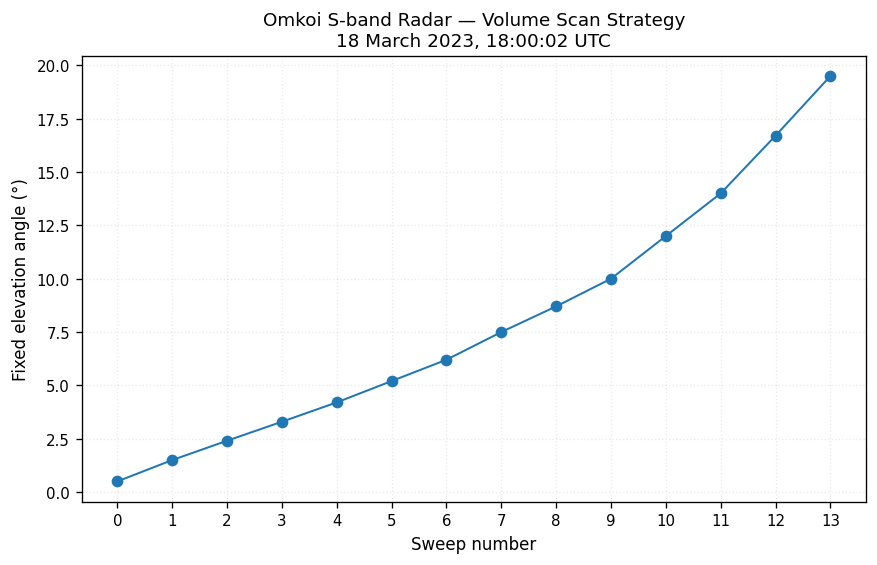

In [15]:
# CELL 15 — Scan-strategy figure
fig=plt.figure(figsize=(7.2,4.6)); ax=fig.add_subplot(111)
ax.plot(sweep_table['sweep'],sweep_table['fixed_angle_deg'],marker='o')
ax.set(xlabel='Sweep number',ylabel='Fixed elevation angle (°)',
       title=f'{site_name} S-band Radar — Volume Scan Strategy\n{utc_time.strftime("%d %B %Y, %H:%M:%S UTC")}')
ax.set_xticks(sweep_table['sweep']); ax.grid(alpha=0.25,linestyle=':')
F=FIGURE_DIR/'02_fig01_scan_elevation_angles.png'
save_figure(fig,F,source_file=selected_filename,field='fixed_angle',processing='UF/Py-ART sweep metadata.',dpi=300)
plt.show()

# 9. Beam geometry: why PPI is not a horizontal map

Using the standard effective-Earth-radius approximation:

\[
R_e^*=kR_e,\qquad k\approx\frac{4}{3}
\]

\[
h=\sqrt{r^2+(kR_e)^2+2rkR_e\sin\theta}-kR_e+h_0
\]

where \(r\) is slant range, \(\theta\) is elevation, and \(h_0\) is radar altitude MSL.

> **RESEARCH NOTE** — the 4/3-Earth model assumes standard refraction; actual propagation can differ.

In [16]:
# CELL 16 — Beam-height function and lowest-sweep table
def beam_height_msl_km(range_km,elevation_deg,radar_altitude_msl_m,
                       earth_radius_km=EARTH_RADIUS_KM,k=EFFECTIVE_EARTH_FACTOR):
    r=np.asarray(range_km,float); th=np.deg2rad(elevation_deg); Re=earth_radius_km*k
    arl=np.sqrt(r*r+Re*Re+2*r*Re*np.sin(th))-Re
    return arl+radar_altitude_msl_m/1000.
beam_ranges=np.array([25,50,100,150,200],float); el0=float(radar.fixed_angle['data'][0])
beam_msl=beam_height_msl_km(beam_ranges,el0,radar_alt_msl)
beam_table=pd.DataFrame({'range_km':beam_ranges,'elevation_deg':el0,
                         'beam_center_height_km_MSL':beam_msl,
                         'beam_center_height_km_ARL':beam_msl-radar_alt_msl/1000.})
display(beam_table)
BEAM_TABLE_CSV=OUTPUT_CSV_DIR/'02_beam_height_lowest_sweep.csv'; beam_table.to_csv(BEAM_TABLE_CSV,index=False)

,range_km,elevation_deg,beam_center_height_km_MSL,beam_center_height_km_ARL
0,25.0,0.5,1.427947,0.254947
1,50.0,0.5,1.756458,0.583458
2,100.0,0.5,2.634133,1.461133
3,150.0,0.5,3.805933,2.632933
4,200.0,0.5,5.271737,4.098737


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_fig02_beam_height_vs_range.png


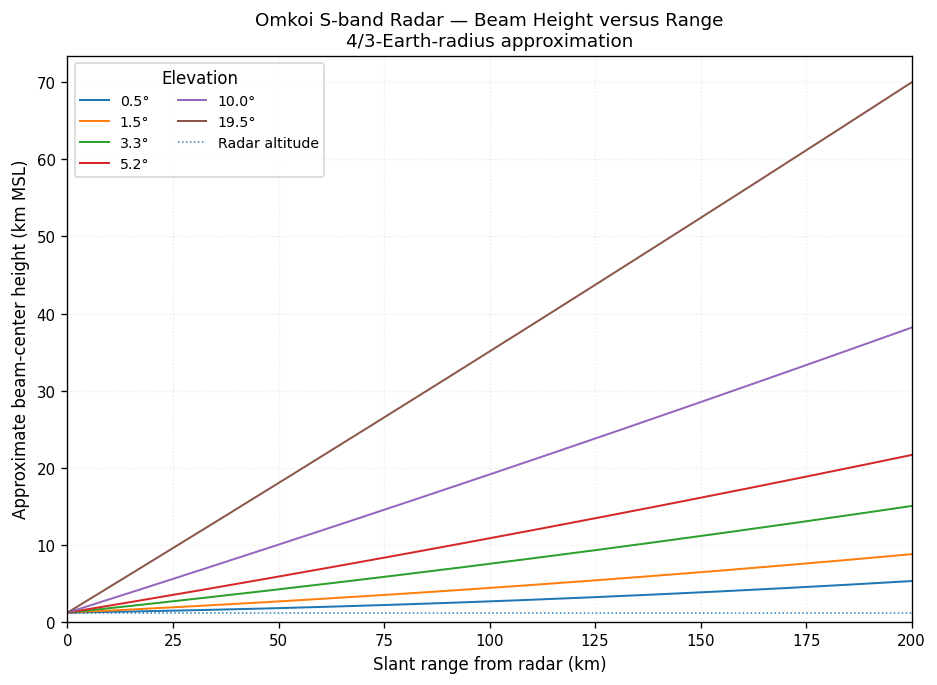

In [17]:
# CELL 17 — Beam-height figure
actual=np.asarray(radar.fixed_angle['data'],float); sel=[]
for target in [0.5,1.5,3.3,5.2,10.,19.5]:
    v=float(actual[np.argmin(np.abs(actual-target))])
    if v not in sel: sel.append(v)
ranges=np.linspace(0,PLOT_RANGE_KM,401)
fig=plt.figure(figsize=(7.7,5.6)); ax=fig.add_subplot(111)
for el in sel:
    ax.plot(ranges,beam_height_msl_km(ranges,el,radar_alt_msl),label=f'{el:.1f}°')
ax.axhline(radar_alt_msl/1000.,linestyle=':',linewidth=0.9,label='Radar altitude')
ax.set(xlabel='Slant range from radar (km)',ylabel='Approximate beam-center height (km MSL)',
       title=f'{site_name} S-band Radar — Beam Height versus Range\n4/3-Earth-radius approximation',
       xlim=(0,PLOT_RANGE_KM),ylim=(0,None))
ax.grid(alpha=0.25,linestyle=':'); ax.legend(title='Elevation',ncol=2)
F=FIGURE_DIR/'02_fig02_beam_height_vs_range.png'
save_figure(fig,F,source_file=selected_filename,field='beam_geometry',processing='4/3 effective Earth radius; height MSL.',dpi=300)
plt.show()

## ARL, MSL and AGL

- **ARL** = above radar level
- **MSL** = mean sea level
- **AGL** = above local ground level

Omkoi radar is at **1.173 km MSL**. Without a DEM, radar-relative height should not be labelled AGL across the whole domain.

# 10. Polar sampling: 500-m gate spacing is not 500-m resolution everywhere

Across rays, approximate spacing increases with range:

\[
\Delta s\approx r\Delta\theta
\]

In [18]:
# CELL 18 — Polar sampling table
n0=int(sweep_table.loc[sweep_table.sweep==0,'n_rays'].iloc[0]); azdeg=360./n0
rr=np.array([25,50,100,150,200],float)
sampling_table=pd.DataFrame({'range_km':rr,'approx_azimuth_spacing_deg':azdeg,
                             'cross_beam_spacing_km':rr*np.deg2rad(azdeg),
                             'along_beam_gate_spacing_km':float(np.nanmedian(np.diff(radar.range['data']))/1000.)})
display(sampling_table)
SAMPLING_CSV=OUTPUT_CSV_DIR/'02_polar_sampling_geometry.csv'; sampling_table.to_csv(SAMPLING_CSV,index=False)

,range_km,approx_azimuth_spacing_deg,cross_beam_spacing_km,along_beam_gate_spacing_km
0,25.0,1.061947,0.463362,0.5
1,50.0,1.061947,0.926723,0.5
2,100.0,1.061947,1.853447,0.5
3,150.0,1.061947,2.780170,0.5
4,200.0,1.061947,3.706894,0.5


# 11. Reflectivity: raw versus corrected

\[
dBZ=10\log_{10}Z
\]

Notebook 02 does not yet convert reflectivity to rainfall. That belongs to Notebook 04.

In [19]:
# CELL 19 — Reflectivity metadata
rows=[]
for f in [FIELD_Z_RAW,FIELD_Z_CORR]:
    m=radar.fields[f]
    rows.append({'field':f,'units':m.get('units'),'standard_name':m.get('standard_name'),
                 'long_name':m.get('long_name'),'_FillValue':m.get('_FillValue'),
                 'valid_min':m.get('valid_min'),'valid_max':m.get('valid_max')})
display(pd.DataFrame(rows))

,field,units,standard_name,long_name,_FillValue,valid_min,valid_max
0,reflectivity,dBZ,equivalent_reflectivity_factor,Reflectivity,-9999.0,None,None
1,corrected_reflectivity,dBZ,corrected_equivalent_reflectivity_factor,Corrected reflectivity,-9999.0,None,None


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_fig03_raw_reflectivity_20230318_180002UTC_EL00.5.png


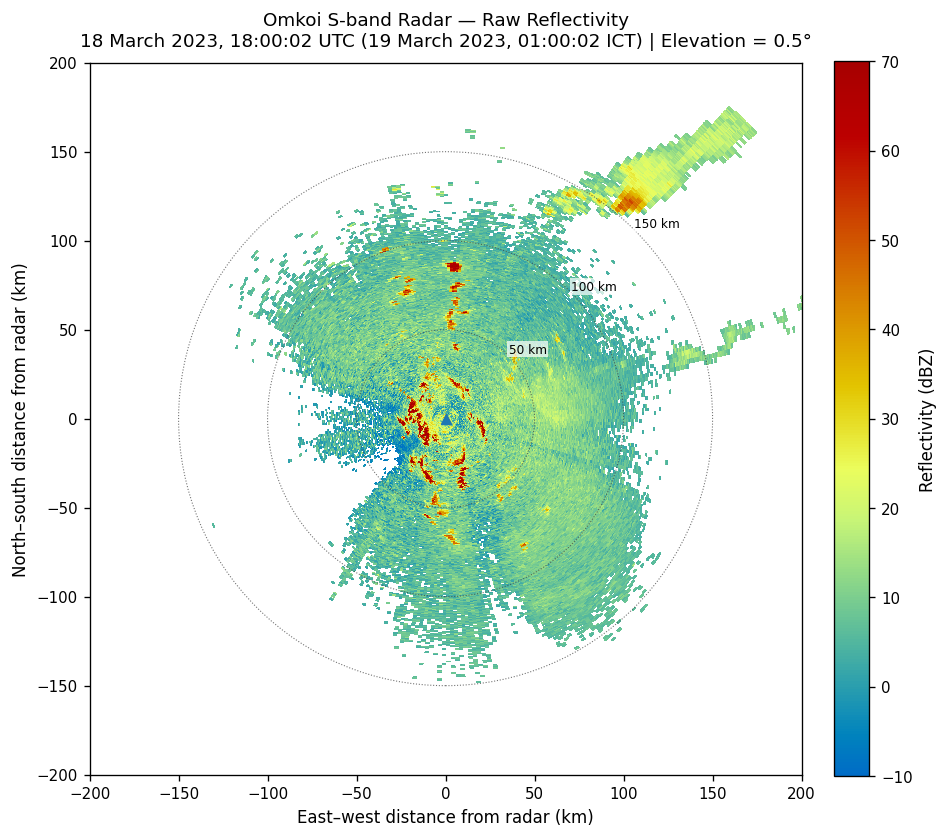

In [20]:
# CELL 20 — Raw reflectivity PPI
raw_z=radar.get_field(SWEEP,FIELD_Z_RAW,copy=True); elev=float(radar.fixed_angle['data'][SWEEP])
title=(f'{site_name} S-band Radar — Raw Reflectivity\n'
       f'{utc_time.strftime("%d %B %Y, %H:%M:%S UTC")} '
       f'({ict_time.strftime("%d %B %Y, %H:%M:%S ICT")}) | Elevation = {elev:.1f}°')
F=FIGURE_DIR/f'02_fig03_raw_reflectivity_{utc_time.strftime("%Y%m%d_%H%M%S")}UTC_EL{elev:04.1f}.png'
plot_native_ppi_array(radar,raw_z,sweep=SWEEP,title=title,colorbar_label='Reflectivity (dBZ)',
                      cmap=CMAP_Z,vmin=Z_MIN,vmax=Z_MAX,output_path=F,source_file=selected_filename,
                      field=FIELD_Z_RAW,processing='Native UF reflectivity; no additional Notebook 02 QC.')

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_fig04_corrected_reflectivity_20230318_180002UTC_EL00.5.png


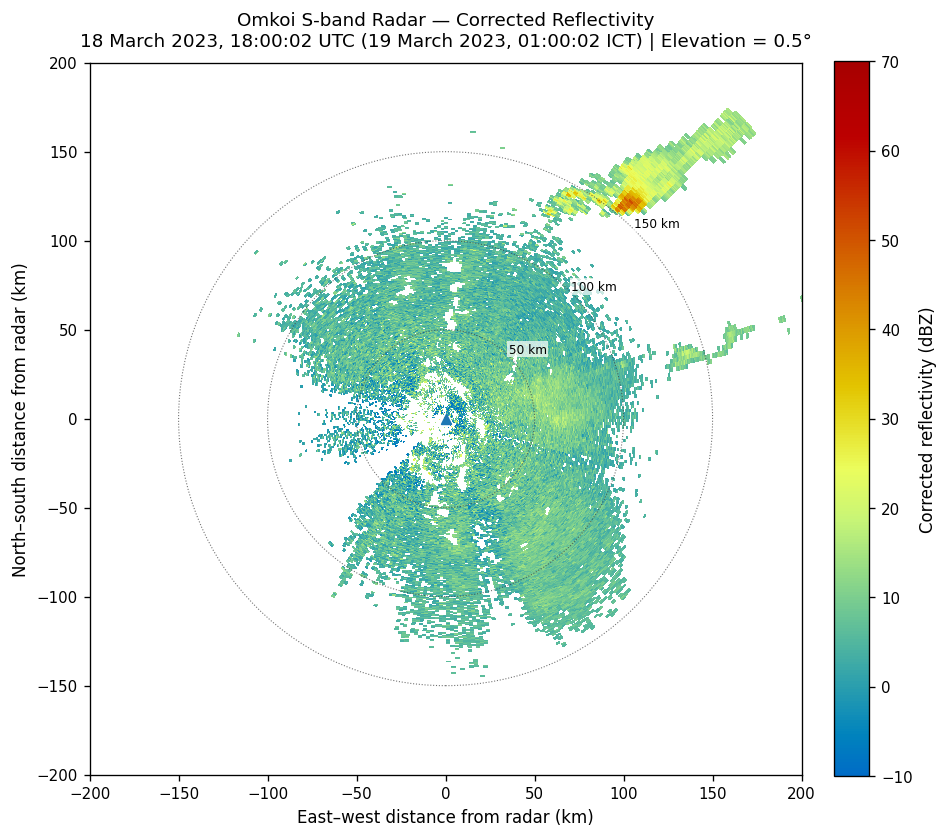

In [21]:
# CELL 21 — Corrected reflectivity PPI
corr_z=radar.get_field(SWEEP,FIELD_Z_CORR,copy=True)
title=(f'{site_name} S-band Radar — Corrected Reflectivity\n'
       f'{utc_time.strftime("%d %B %Y, %H:%M:%S UTC")} '
       f'({ict_time.strftime("%d %B %Y, %H:%M:%S ICT")}) | Elevation = {elev:.1f}°')
F=FIGURE_DIR/f'02_fig04_corrected_reflectivity_{utc_time.strftime("%Y%m%d_%H%M%S")}UTC_EL{elev:04.1f}.png'
plot_native_ppi_array(radar,corr_z,sweep=SWEEP,title=title,colorbar_label='Corrected reflectivity (dBZ)',
                      cmap=CMAP_Z,vmin=Z_MIN,vmax=Z_MAX,output_path=F,source_file=selected_filename,
                      field=FIELD_Z_CORR,processing='Corrected reflectivity supplied in source UF data.')

# 12. Common-valid-gate comparison

Use

\[
M=valid(Z_{raw})\cap valid(Z_{corr})
\]

then

\[
\Delta Z_H=Z_{corr}-Z_{raw}
\]

Only gates valid in both fields are compared. \(\Delta Z_H\) is a difference, not an error.

In [22]:
# CELL 22 — Common mask and statistics
raw=np.ma.asarray(raw_z); corr=np.ma.asarray(corr_z)
common=(~np.ma.getmaskarray(raw) & ~np.ma.getmaskarray(corr) &
        np.isfinite(raw.filled(np.nan)) & np.isfinite(corr.filled(np.nan)))
raw_common=np.asarray(raw.filled(np.nan))[common]; corr_common=np.asarray(corr.filled(np.nan))[common]
delta_common=corr_common-raw_common
delta_z=np.ma.masked_all(raw.shape,dtype=float); delta_z[common]=delta_common
if delta_common.size==0: raise RuntimeError('No common valid raw/corrected gates.')
stats=pd.DataFrame({'metric':['common_gate_count','raw_median_dBZ','corrected_median_dBZ',
                              'delta_median_dB','delta_P05_dB','delta_P95_dB','difference_RMS_dB'],
                    'value':[int(delta_common.size),float(np.nanmedian(raw_common)),float(np.nanmedian(corr_common)),
                             float(np.nanmedian(delta_common)),float(np.nanpercentile(delta_common,5)),
                             float(np.nanpercentile(delta_common,95)),float(np.sqrt(np.nanmean(delta_common**2)))]})
display(stats)
DELTA_STATS_CSV=OUTPUT_CSV_DIR/'02_reflectivity_common_mask_stats.csv'; stats.to_csv(DELTA_STATS_CSV,index=False)

,metric,value
0,common_gate_count,50595.000000
1,raw_median_dBZ,9.000000
2,corrected_median_dBZ,7.000000
3,delta_median_dB,-1.500000
4,delta_P05_dB,-7.500000
5,delta_P95_dB,0.000000
6,difference_RMS_dB,3.257812


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_fig05_reflectivity_difference.png


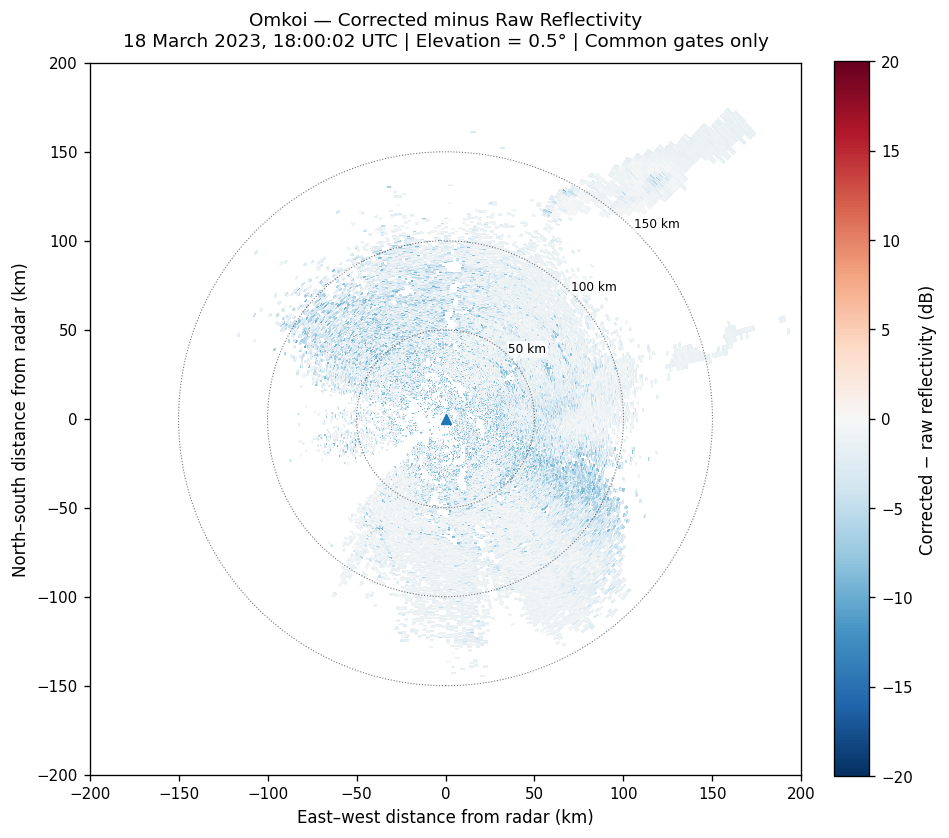

In [23]:
# CELL 23 — Reflectivity difference PPI
F=FIGURE_DIR/'02_fig05_reflectivity_difference.png'
plot_native_ppi_array(radar,delta_z,sweep=SWEEP,
                      title=f'{site_name} — Corrected minus Raw Reflectivity\n{utc_time.strftime("%d %B %Y, %H:%M:%S UTC")} | Elevation = {elev:.1f}° | Common gates only',
                      colorbar_label='Corrected − raw reflectivity (dB)',cmap=CMAP_DIFF,
                      vmin=-DELTA_Z_LIMIT,vmax=DELTA_Z_LIMIT,output_path=F,source_file=selected_filename,
                      field='corrected_minus_raw_reflectivity',processing='Difference on common valid gates only.')

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_fig06_reflectivity_difference_distribution.png


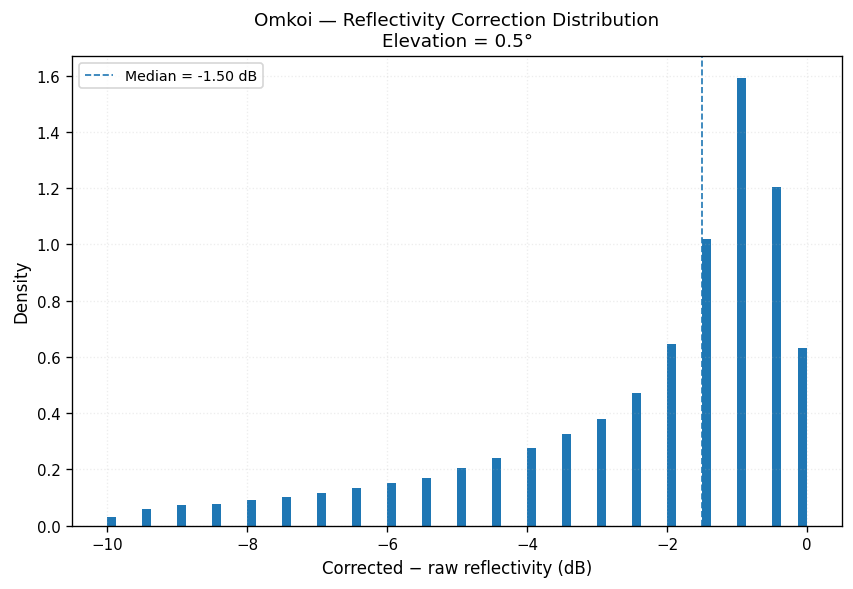

In [24]:
# CELL 24 — Correction distribution
fig=plt.figure(figsize=(7.0,4.8)); ax=fig.add_subplot(111)
ax.hist(delta_common,bins=80,density=True)
ax.axvline(np.nanmedian(delta_common),linestyle='--',linewidth=1.0,
           label=f'Median = {np.nanmedian(delta_common):.2f} dB')
ax.set(xlabel='Corrected − raw reflectivity (dB)',ylabel='Density',
       title=f'{site_name} — Reflectivity Correction Distribution\nElevation = {elev:.1f}°')
ax.grid(alpha=0.22,linestyle=':'); ax.legend()
F=FIGURE_DIR/'02_fig06_reflectivity_difference_distribution.png'
save_figure(fig,F,source_file=selected_filename,field='corrected_minus_raw_reflectivity',
            sweep=SWEEP,elevation_deg=elev,time_UTC=str(utc_time),time_ICT=str(ict_time),
            processing='Common-valid-gate distribution.',dpi=300)
plt.show()

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_fig07_raw_vs_corrected_reflectivity.png


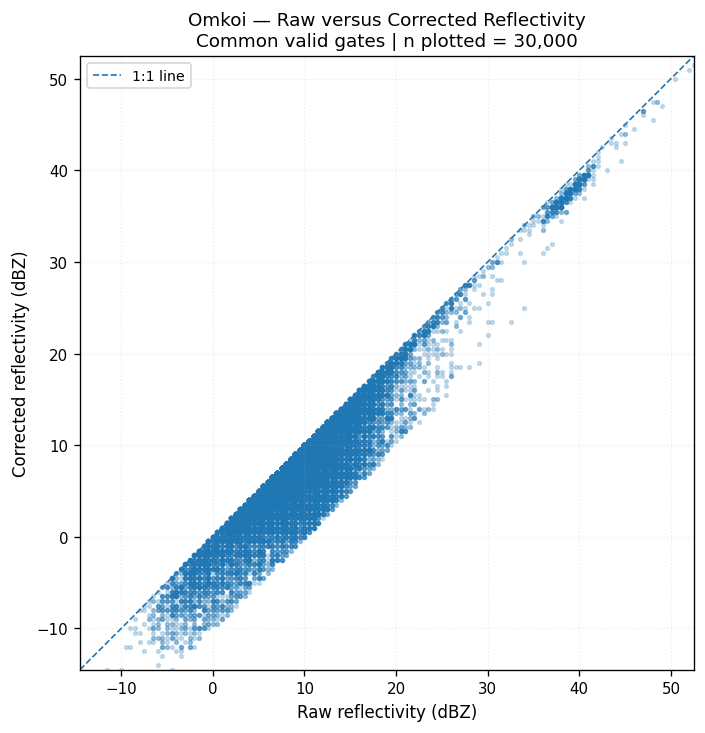

In [25]:
# CELL 25 — Raw vs corrected scatter
MAX_SCATTER_POINTS=30000; rng=np.random.default_rng(42)
idx=rng.choice(raw_common.size,size=MAX_SCATTER_POINTS,replace=False) if raw_common.size>MAX_SCATTER_POINTS else np.arange(raw_common.size)
x=raw_common[idx]; y=corr_common[idx]; lo=float(np.nanmin([x.min(),y.min()])); hi=float(np.nanmax([x.max(),y.max()]))
fig=plt.figure(figsize=(6.2,6.0)); ax=fig.add_subplot(111)
ax.scatter(x,y,s=5,alpha=0.22,rasterized=True); ax.plot([lo,hi],[lo,hi],linestyle='--',linewidth=1.0,label='1:1 line')
ax.set(xlim=(lo,hi),ylim=(lo,hi),xlabel='Raw reflectivity (dBZ)',ylabel='Corrected reflectivity (dBZ)',
       title=f'{site_name} — Raw versus Corrected Reflectivity\nCommon valid gates | n plotted = {len(idx):,}')
ax.set_aspect('equal',adjustable='box'); ax.grid(alpha=0.22,linestyle=':'); ax.legend()
F=FIGURE_DIR/'02_fig07_raw_vs_corrected_reflectivity.png'
save_figure(fig,F,source_file=selected_filename,field=f'{FIELD_Z_RAW};{FIELD_Z_CORR}',
            sweep=SWEEP,elevation_deg=elev,time_UTC=str(utc_time),time_ICT=str(ict_time),
            processing='Reproducible random sample of common valid gates.',dpi=300)
plt.show()

## RESEARCH NOTE — isolated extreme raw reflectivity

Notebook 01 found raw maxima near 88–89 dBZ while corrected values were much lower. Do not equate an extreme raw gate with hail. It may represent meteorological or non-meteorological effects and must be evaluated spatially and physically.

# 13. Doppler radial velocity and Nyquist velocity

\[
V_r=\vec{V}\cdot\hat{r}
\]

The radar observes the beam-parallel component, not the complete wind vector.

In [26]:
# CELL 26 — Velocity metadata + Nyquist
m=radar.fields[FIELD_VEL]
display(pd.DataFrame({'metadata':['units','standard_name','long_name','valid_min','valid_max'],
                      'value':[m.get('units'),m.get('standard_name'),m.get('long_name'),m.get('valid_min'),m.get('valid_max')]}))
nyquist=float(radar.get_nyquist_vel(SWEEP,check_uniform=False)); print(f'Nyquist = ±{nyquist:.2f} m s⁻¹')

,metadata,value
0,units,meters_per_second
1,standard_name,radial_velocity_of_scatterers_away_from_instru...
2,long_name,Mean dopper velocity
3,valid_min,None
4,valid_max,None


Nyquist = ±16.70 m s⁻¹


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_fig08_raw_velocity.png


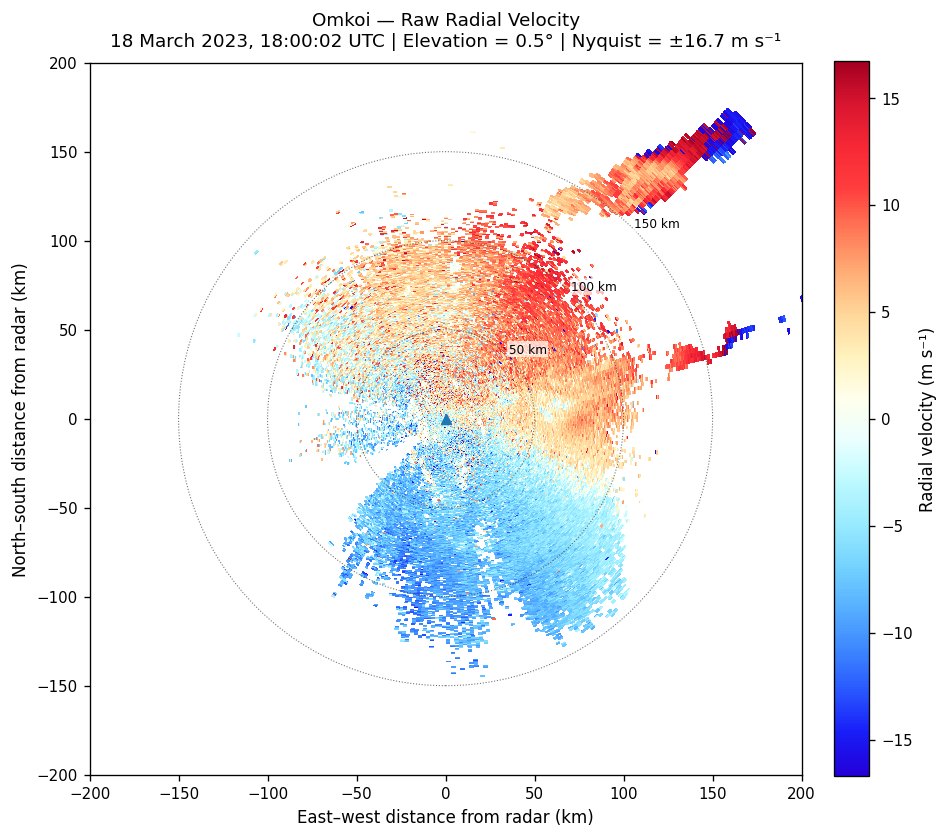

In [27]:
# CELL 27 — Raw velocity PPI
raw_velocity=radar.get_field(SWEEP,FIELD_VEL,copy=True)
F=FIGURE_DIR/'02_fig08_raw_velocity.png'
plot_native_ppi_array(radar,raw_velocity,sweep=SWEEP,
                      title=f'{site_name} — Raw Radial Velocity\n{utc_time.strftime("%d %B %Y, %H:%M:%S UTC")} | Elevation = {elev:.1f}° | Nyquist = ±{nyquist:.1f} m s⁻¹',
                      colorbar_label='Radial velocity (m s⁻¹)',cmap=CMAP_V,vmin=-nyquist,vmax=nyquist,
                      output_path=F,source_file=selected_filename,field=FIELD_VEL,
                      processing='Native radial velocity before dealiasing.')

# 14. Candidate velocity folding

Values near \(\pm V_N\) are useful places to inspect for folding, but being close to Nyquist does not by itself prove aliasing.

In [28]:
# CELL 28 — Nyquist table and near-Nyquist diagnostic
rows=[]
for s in range(radar.nsweeps):
    rows.append({'sweep':s,'elevation_deg':float(radar.fixed_angle['data'][s]),
                 'nyquist_velocity_ms':float(radar.get_nyquist_vel(s,check_uniform=False))})
nyquist_table=pd.DataFrame(rows); display(nyquist_table)
NYQUIST_CSV=OUTPUT_CSV_DIR/'02_scan_nyquist_velocity.csv'; nyquist_table.to_csv(NYQUIST_CSV,index=False)
vv=np.ma.asarray(raw_velocity).compressed(); vv=vv[np.isfinite(vv)]
near=float((np.abs(vv)>=0.95*nyquist).mean()) if vv.size else np.nan
folding_diagnostic=pd.DataFrame({'metric':['valid_velocity_gate_count','nyquist_velocity_ms','fraction_abs_velocity_ge_0.95Nyquist'],
                                 'value':[int(vv.size),nyquist,near]})
display(folding_diagnostic)

,sweep,elevation_deg,nyquist_velocity_ms
0,0,0.500000,16.700001
1,1,1.500000,16.700001
2,2,2.406250,16.700001
3,3,3.296875,16.700001
4,4,4.203125,16.700001
5,5,5.203125,16.700001
6,6,6.203125,16.700001
7,7,7.500000,16.700001
8,8,8.703125,16.700001
9,9,10.000000,16.700001


,metric,value
0,valid_velocity_gate_count,60203.000000
1,nyquist_velocity_ms,16.700001
2,fraction_abs_velocity_ge_0.95Nyquist,0.005315


# 15. Region-based Doppler dealiasing

Py-ART's region-based algorithm unfolds and merges regions of similar velocity. Notebook 02 creates a new field and preserves the raw measurement.

A reflectivity-conditioned gate filter is used for this teaching example:

```text
valid velocity
+ valid corrected ZH
+ corrected ZH ≥ DEALIAS_Z_MIN_DBZ
```

> **RESEARCH NOTE** — dealiasing output must still be checked for discontinuities and artifacts before severe-storm shear analysis.

In [29]:
# CELL 29 — Region-based dealiasing
gf=pyart.filters.GateFilter(radar)
gf.exclude_invalid(FIELD_VEL); gf.exclude_masked(FIELD_VEL)
gf.exclude_invalid(FIELD_Z_CORR); gf.exclude_below(FIELD_Z_CORR,DEALIAS_Z_MIN_DBZ)
print('Running region-based dealiasing ...')
field=pyart.correct.dealias_region_based(radar,vel_field=FIELD_VEL,gatefilter=gf,
                                        centered=True,check_nyquist_uniform=True,
                                        keep_original=False,set_limits=True)
radar.add_field(FIELD_VEL_DEALIASED,field,replace_existing=True)
print('Added:', FIELD_VEL_DEALIASED)

Running region-based dealiasing ...
Added: velocity_dealiased


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_fig09_dealiased_velocity.png


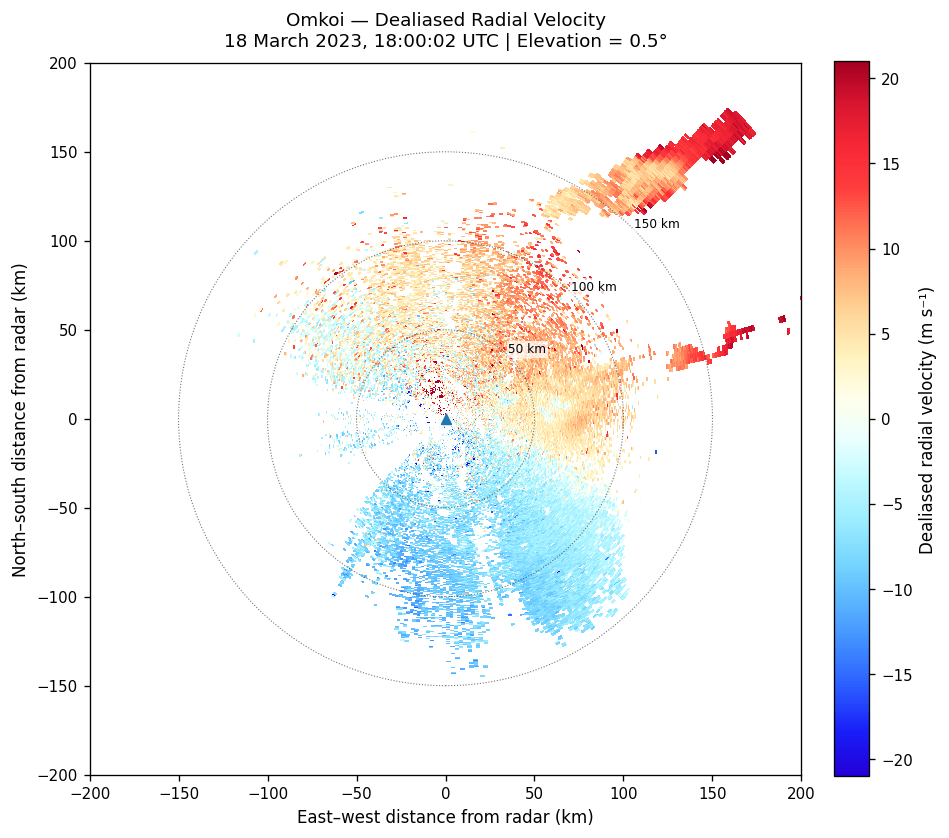

In [30]:
# CELL 30 — Dealiased velocity PPI
dealiased_velocity=radar.get_field(SWEEP,FIELD_VEL_DEALIASED,copy=True)
dv=np.ma.asarray(dealiased_velocity).compressed(); dv=dv[np.isfinite(dv)]
vel_limit=max(nyquist,float(np.nanpercentile(np.abs(dv),99))) if dv.size else nyquist
vel_limit=float(np.ceil(vel_limit))
F=FIGURE_DIR/'02_fig09_dealiased_velocity.png'
plot_native_ppi_array(radar,dealiased_velocity,sweep=SWEEP,
                      title=f'{site_name} — Dealiased Radial Velocity\n{utc_time.strftime("%d %B %Y, %H:%M:%S UTC")} | Elevation = {elev:.1f}°',
                      colorbar_label='Dealiased radial velocity (m s⁻¹)',cmap=CMAP_V,
                      vmin=-vel_limit,vmax=vel_limit,output_path=F,source_file=selected_filename,
                      field=FIELD_VEL_DEALIASED,
                      processing=f'Py-ART region-based dealiasing; ZHcorr >= {DEALIAS_Z_MIN_DBZ:.1f} dBZ gate filter.')

,metric,value
0,common_valid_gate_count,33047.000000
1,fraction_abs_change_gt_1_ms,0.020637
2,median_abs_change_ms,0.000000
3,P95_abs_change_ms,0.000000
4,2_times_Nyquist_ms,33.400002


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_fig10_dealiased_minus_raw_velocity.png


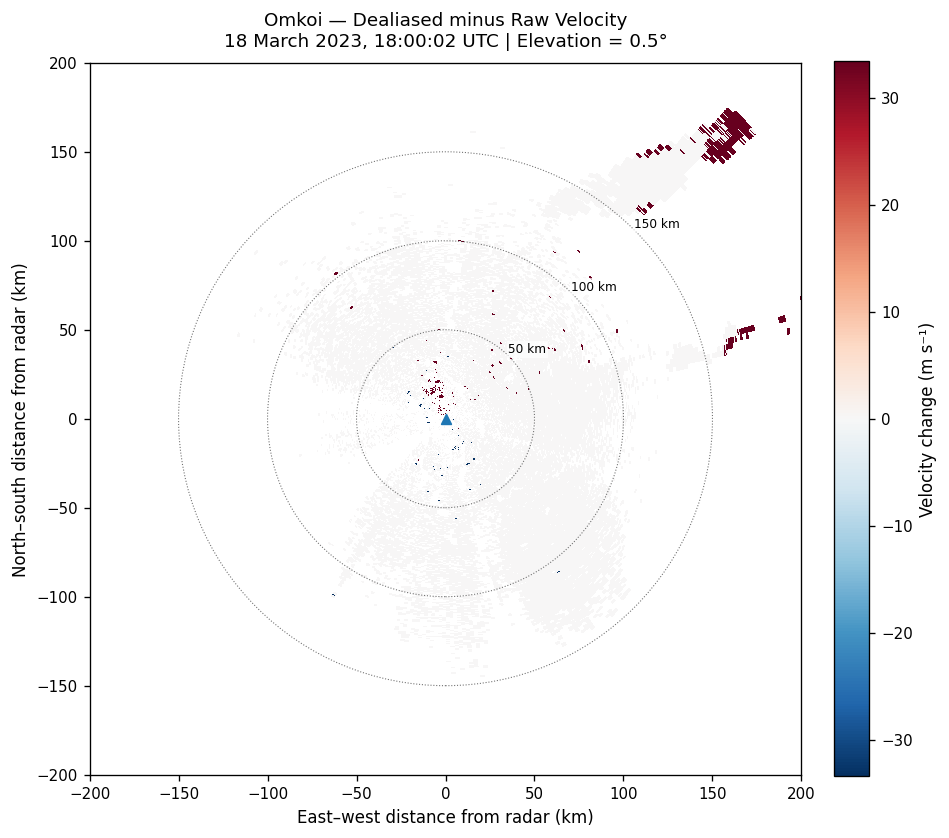

In [31]:
# CELL 31 — Dealiasing change statistics and map
rv=np.ma.asarray(raw_velocity); dv2=np.ma.asarray(dealiased_velocity)
commonv=(~np.ma.getmaskarray(rv)&~np.ma.getmaskarray(dv2)&np.isfinite(rv.filled(np.nan))&np.isfinite(dv2.filled(np.nan)))
rawc=np.asarray(rv.filled(np.nan))[commonv]; dealc=np.asarray(dv2.filled(np.nan))[commonv]; change=dealc-rawc
summary=pd.DataFrame({'metric':['common_valid_gate_count','fraction_abs_change_gt_1_ms','median_abs_change_ms','P95_abs_change_ms','2_times_Nyquist_ms'],
                      'value':[int(change.size),float((np.abs(change)>1).mean()) if change.size else np.nan,
                               float(np.nanmedian(np.abs(change))) if change.size else np.nan,
                               float(np.nanpercentile(np.abs(change),95)) if change.size else np.nan,2*nyquist]})
display(summary)
DEALIAS_CSV=OUTPUT_CSV_DIR/'02_velocity_dealiasing_summary.csv'; summary.to_csv(DEALIAS_CSV,index=False)
delta=np.ma.masked_all(rv.shape,dtype=float); delta[commonv]=change
F=FIGURE_DIR/'02_fig10_dealiased_minus_raw_velocity.png'
plot_native_ppi_array(radar,delta,sweep=SWEEP,
                      title=f'{site_name} — Dealiased minus Raw Velocity\n{utc_time.strftime("%d %B %Y, %H:%M:%S UTC")} | Elevation = {elev:.1f}°',
                      colorbar_label='Velocity change (m s⁻¹)',cmap=CMAP_DIFF,vmin=-2*nyquist,vmax=2*nyquist,
                      output_path=F,source_file=selected_filename,field='velocity_dealiased_minus_raw',
                      processing='Difference on common valid velocity gates.')

## ADVANCED — why changes near \(2V_N\) matter

A one-fold correction often changes velocity by approximately

\[
2V_N\approx33.4\;m\,s^{-1}
\]

This is a useful diagnostic signature, not proof that every changed gate is correct.

# 16. Doppler spectrum width

Spectrum width describes the spread of Doppler velocities within a radar sampling volume. Large values can arise from several processes; it should not be used as a direct turbulence indicator without additional evidence.

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_fig11_spectrum_width.png


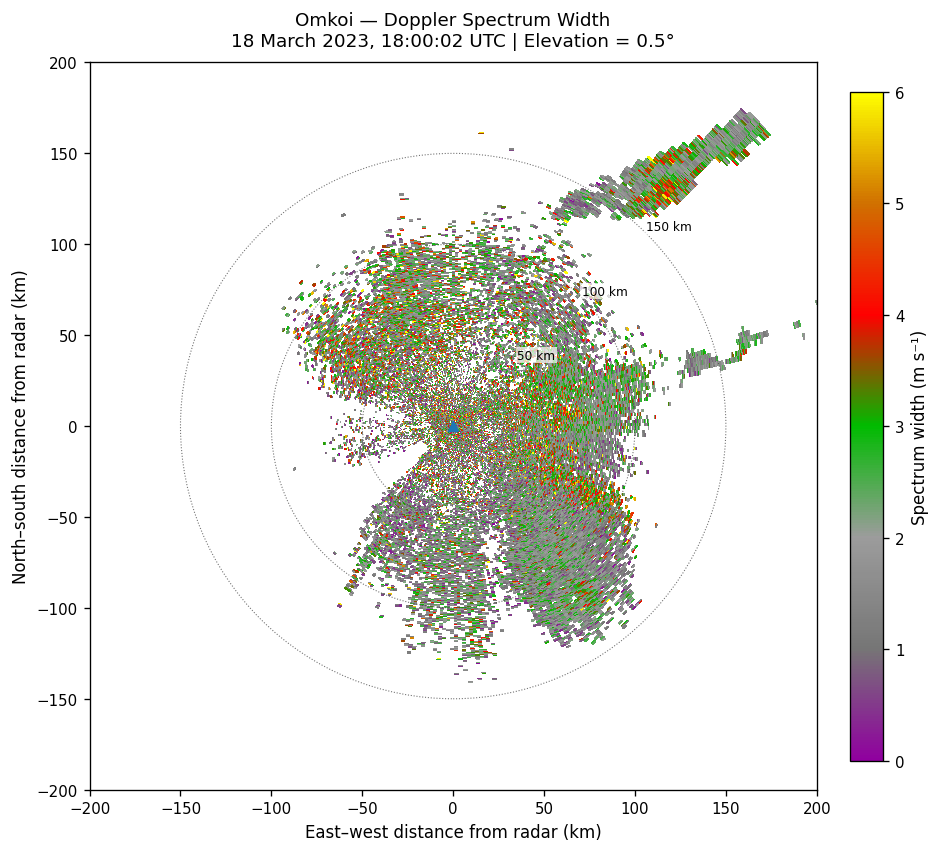

In [32]:
# CELL 32 — Spectrum-width PPI
sw=radar.get_field(SWEEP,FIELD_SW,copy=True); vals=np.ma.asarray(sw).compressed(); vals=vals[np.isfinite(vals)]
SW_MAX=max(5.,float(np.ceil(np.nanpercentile(vals,99)))) if vals.size else 10.
F=FIGURE_DIR/'02_fig11_spectrum_width.png'
plot_native_ppi_array(radar,sw,sweep=SWEEP,
                      title=f'{site_name} — Doppler Spectrum Width\n{utc_time.strftime("%d %B %Y, %H:%M:%S UTC")} | Elevation = {elev:.1f}°',
                      colorbar_label='Spectrum width (m s⁻¹)',cmap=CMAP_SW,vmin=0.,vmax=SW_MAX,
                      output_path=F,source_file=selected_filename,field=FIELD_SW,processing='Native Doppler spectrum width.')

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_fig12_spectrum_width_distribution.png


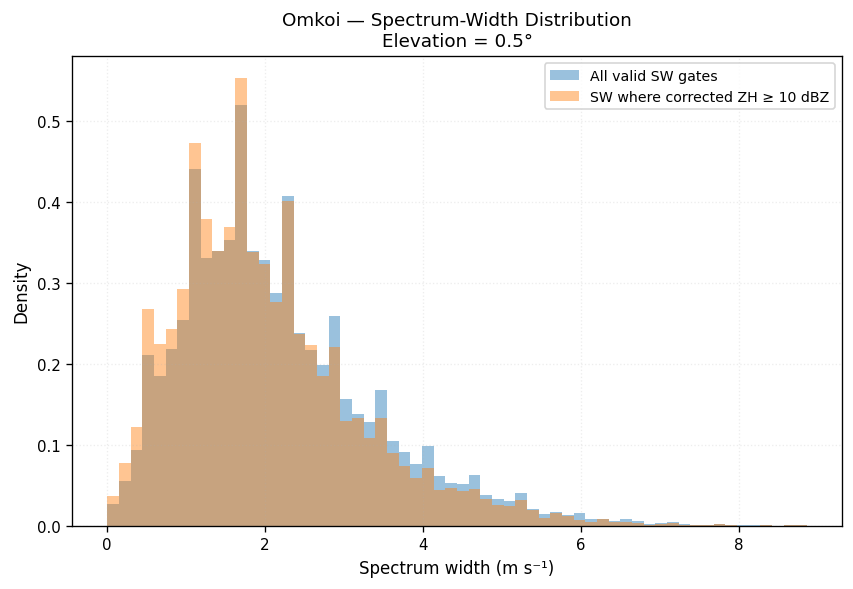

In [33]:
# CELL 33 — Spectrum-width distribution conditioned by reflectivity
swa=np.ma.asarray(sw); zca=np.ma.asarray(corr_z)
all_sw=np.asarray(swa.filled(np.nan))[~np.ma.getmaskarray(swa)]; all_sw=all_sw[np.isfinite(all_sw)]
cond=(~np.ma.getmaskarray(swa)&~np.ma.getmaskarray(zca)&np.isfinite(swa.filled(np.nan))&
      np.isfinite(zca.filled(np.nan))&(zca.filled(-999)>=SW_Z_MIN_DBZ))
precip_sw=np.asarray(swa.filled(np.nan))[cond]
fig=plt.figure(figsize=(7.0,4.8)); ax=fig.add_subplot(111)
ax.hist(all_sw,bins=60,density=True,alpha=0.45,label='All valid SW gates')
if precip_sw.size:
    ax.hist(precip_sw,bins=60,density=True,alpha=0.45,label=f'SW where corrected ZH ≥ {SW_Z_MIN_DBZ:.0f} dBZ')
ax.set(xlabel='Spectrum width (m s⁻¹)',ylabel='Density',title=f'{site_name} — Spectrum-Width Distribution\nElevation = {elev:.1f}°')
ax.grid(alpha=0.22,linestyle=':'); ax.legend()
F=FIGURE_DIR/'02_fig12_spectrum_width_distribution.png'
save_figure(fig,F,source_file=selected_filename,field=FIELD_SW,sweep=SWEEP,elevation_deg=elev,
            time_UTC=str(utc_time),time_ICT=str(ict_time),
            processing=f'All SW gates vs SW conditioned on corrected ZH >= {SW_Z_MIN_DBZ:.1f} dBZ.',dpi=300)
plt.show()

# 17. Multi-elevation echo structure

Representative elevations are plotted separately using exactly the same reflectivity scale and domain. These are still PPI surfaces, not a vertical cross-section.

In [34]:
# CELL 34 — Match target elevations
angles=np.asarray(radar.fixed_angle['data'],float); selected_sweeps=[]
for target in TARGET_ELEVATIONS_DEG:
    s=int(np.argmin(np.abs(angles-target)))
    if s not in selected_sweeps: selected_sweeps.append(s)
multi_sweep_table=pd.DataFrame({'sweep':selected_sweeps,'elevation_deg':[float(angles[s]) for s in selected_sweeps]})
display(multi_sweep_table)

,sweep,elevation_deg
0,0,0.500000
1,1,1.500000
2,3,3.296875
3,5,5.203125
4,8,8.703125
5,10,12.000000
6,12,16.703125
7,13,19.500000


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_multiEL_corrected_reflectivity_EL00.5.png


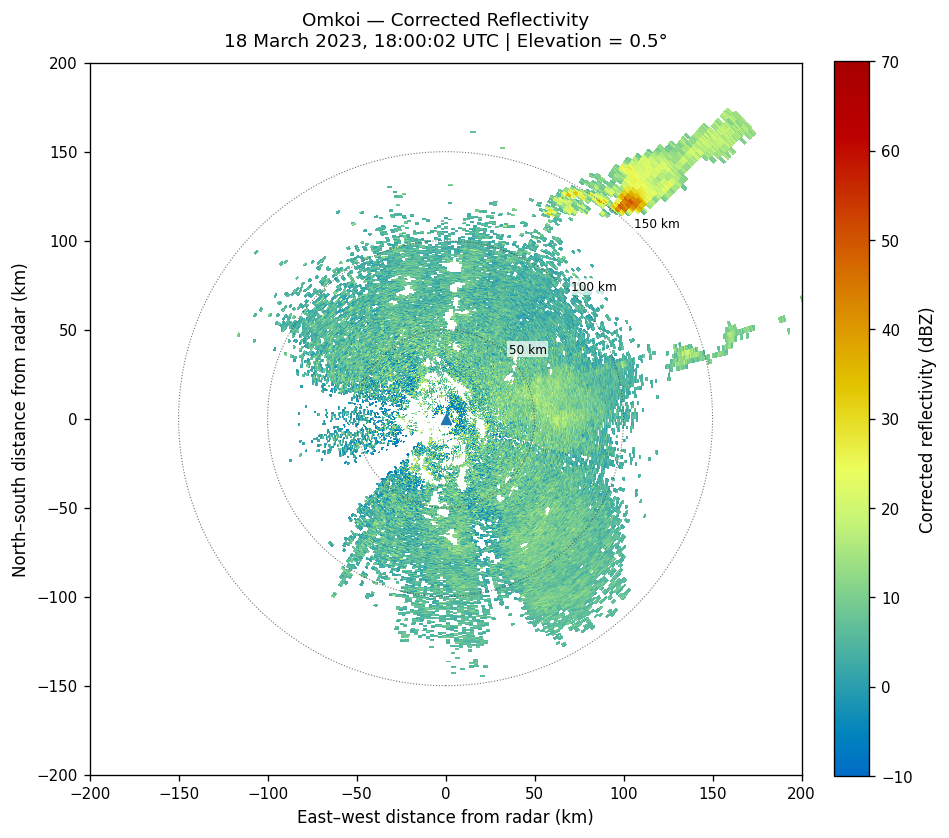

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_multiEL_corrected_reflectivity_EL01.5.png


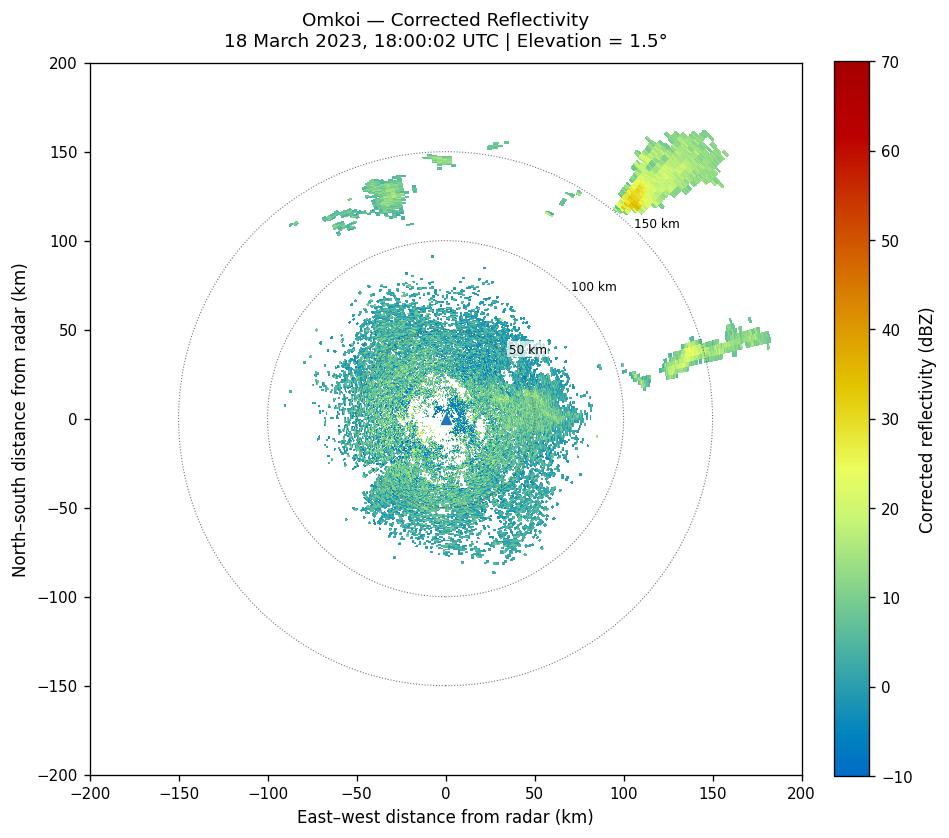

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_multiEL_corrected_reflectivity_EL03.3.png


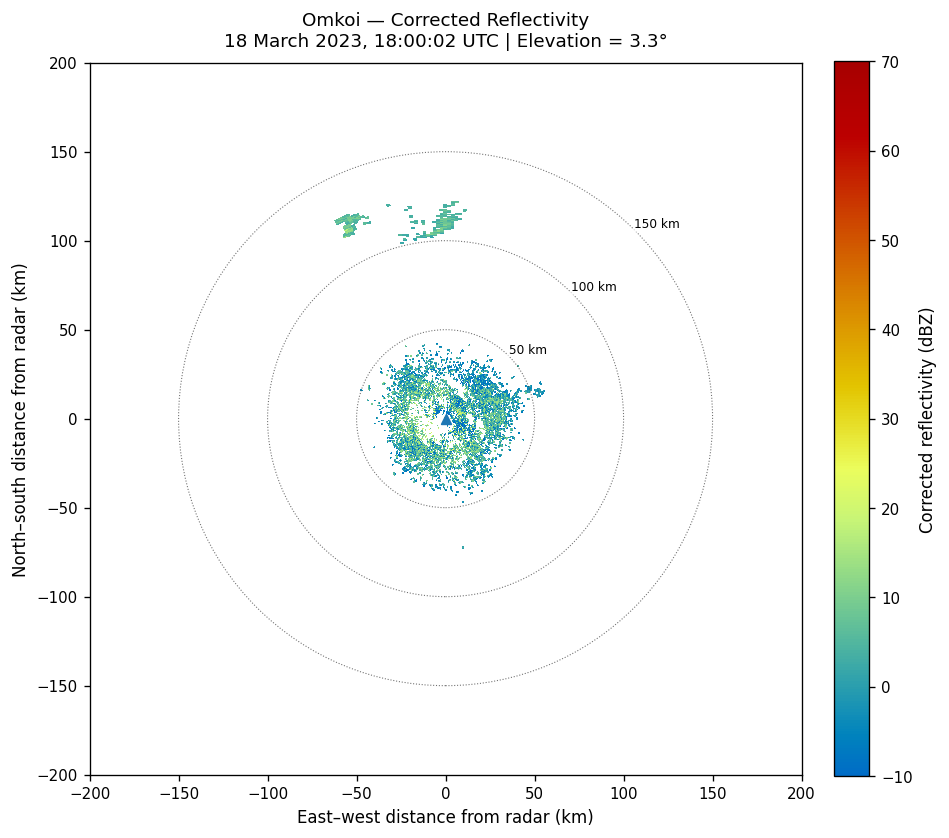

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_multiEL_corrected_reflectivity_EL05.2.png


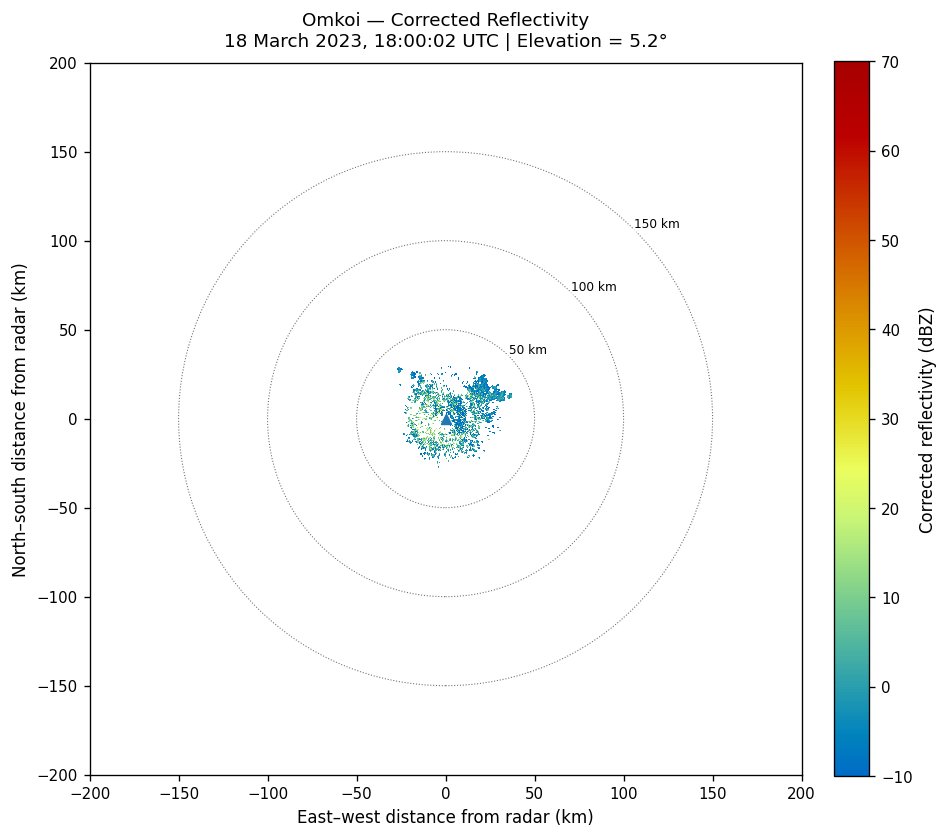

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_multiEL_corrected_reflectivity_EL08.7.png


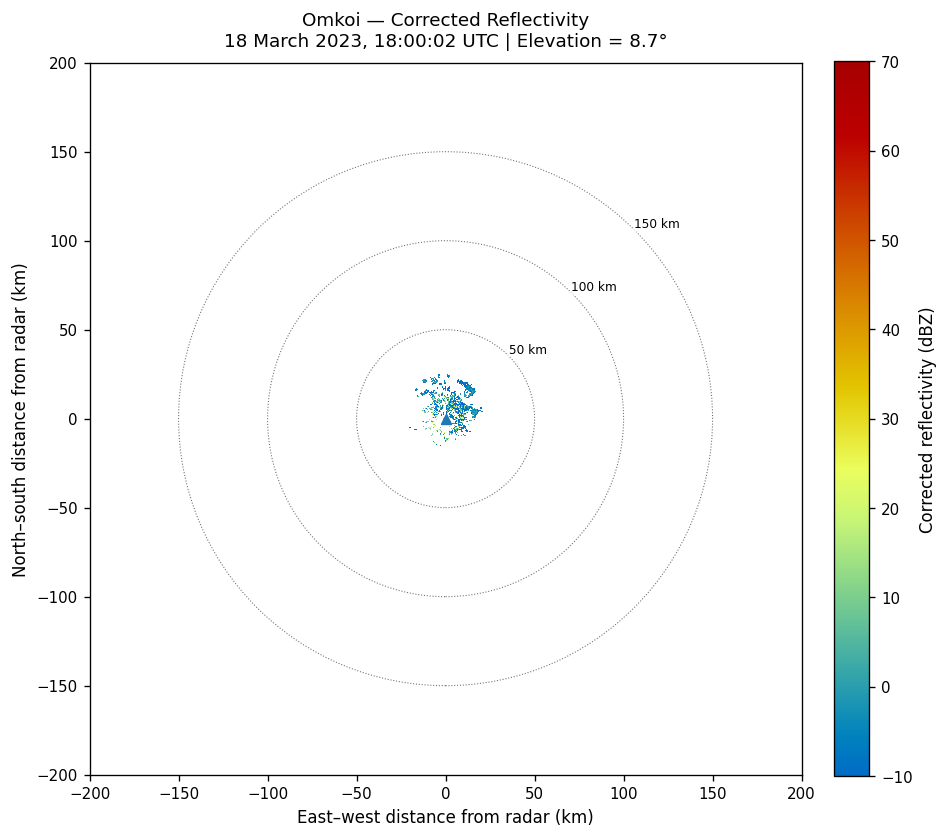

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_multiEL_corrected_reflectivity_EL12.0.png


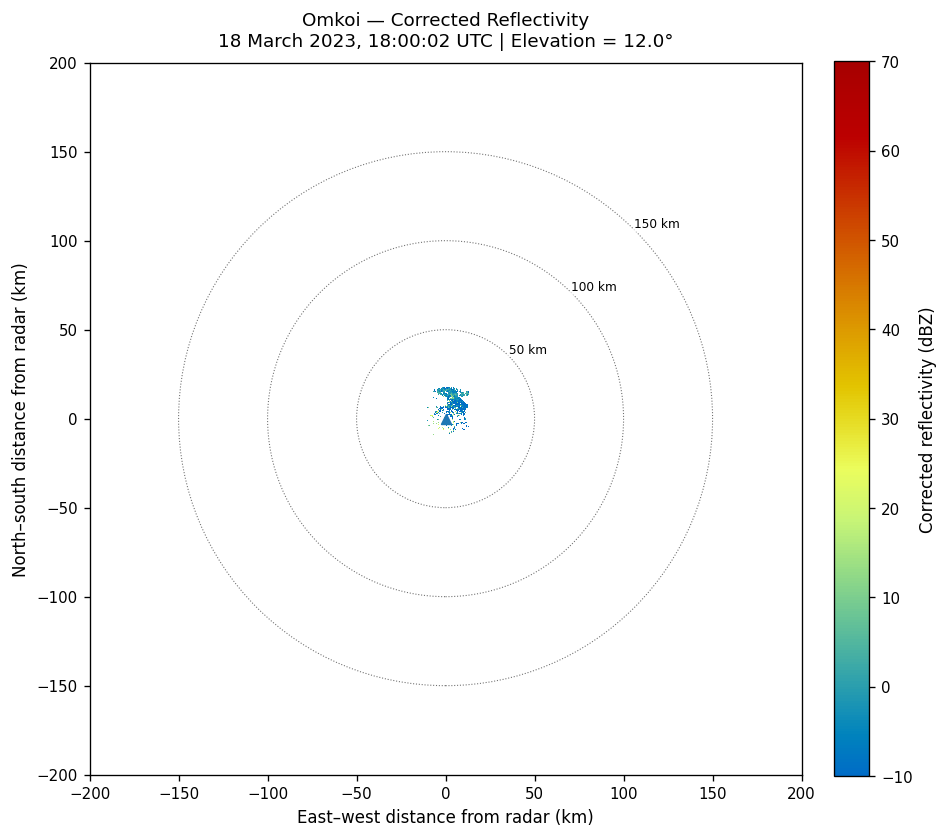

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_multiEL_corrected_reflectivity_EL16.7.png


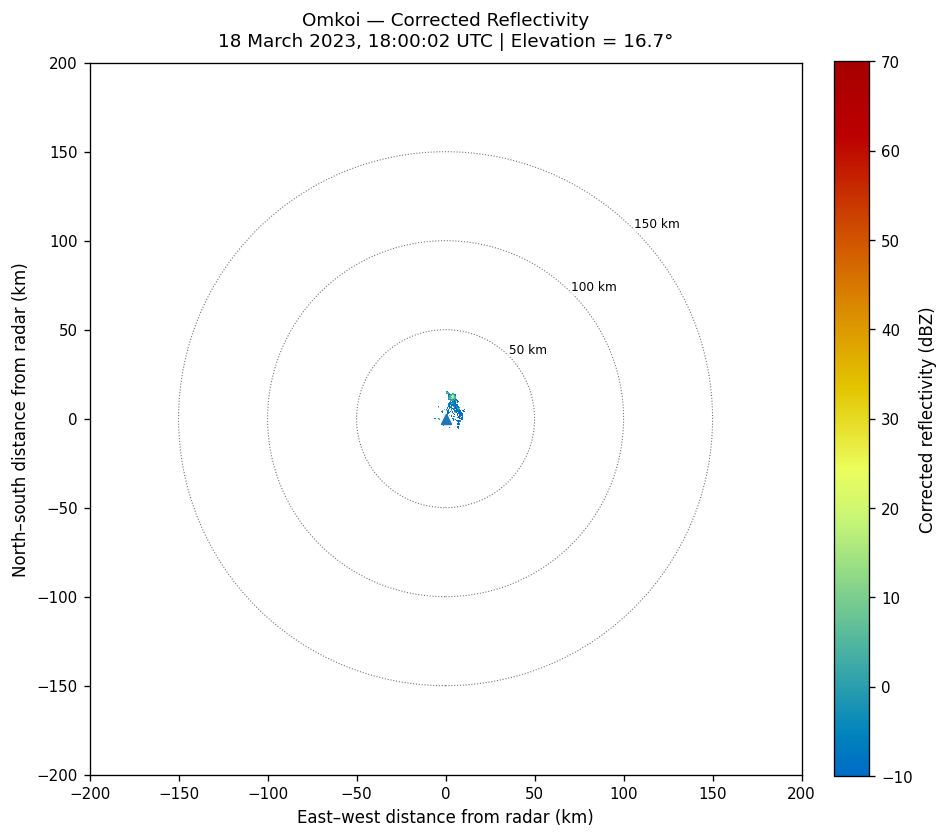

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_multiEL_corrected_reflectivity_EL19.5.png


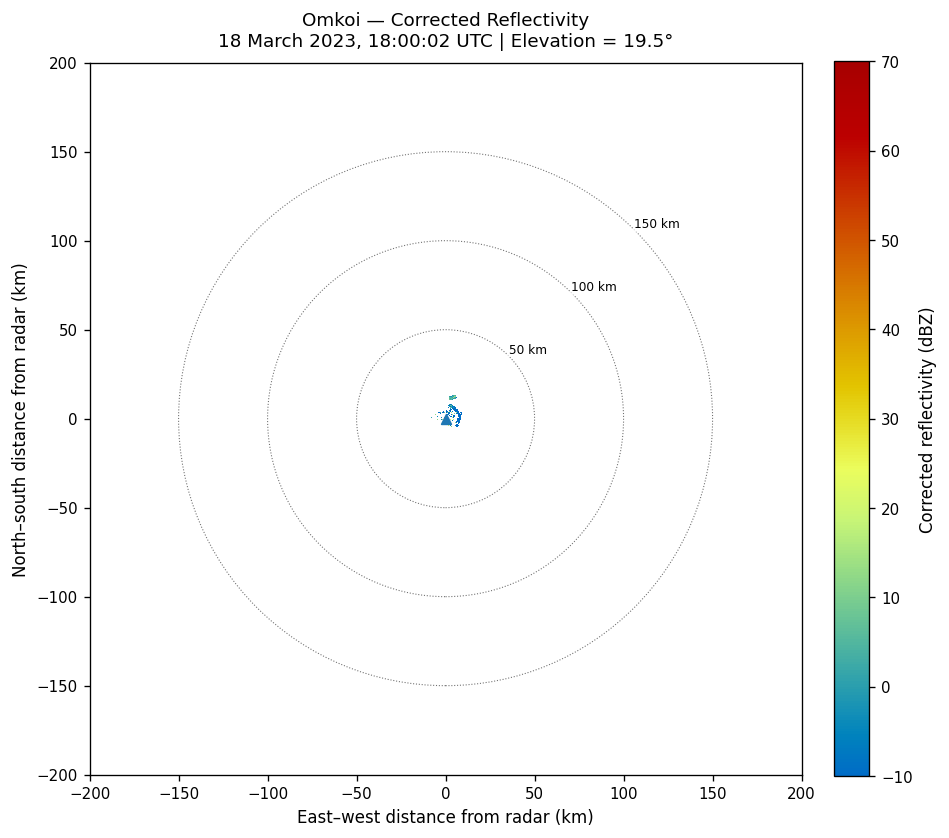

In [35]:
# CELL 35 — Export selected-elevation PPI figures
for s in selected_sweeps:
    el=float(radar.fixed_angle['data'][s]); z=radar.get_field(s,FIELD_Z_CORR,copy=True)
    F=FIGURE_DIR/f'02_multiEL_corrected_reflectivity_EL{el:04.1f}.png'
    plot_native_ppi_array(radar,z,sweep=s,
                          title=f'{site_name} — Corrected Reflectivity\n{utc_time.strftime("%d %B %Y, %H:%M:%S UTC")} | Elevation = {el:.1f}°',
                          colorbar_label='Corrected reflectivity (dBZ)',cmap=CMAP_Z,vmin=Z_MIN,vmax=Z_MAX,
                          output_path=F,source_file=selected_filename,field=FIELD_Z_CORR,
                          processing='Selected-elevation PPI; identical reflectivity scale.')

## RESEARCH NOTE — gate count is not physical area

In polar coordinates, gate geometry changes with range. Gate counts above a reflectivity threshold are useful descriptors but must not be reported as storm area. Physical area/volume will be calculated after Cartesian gridding.

In [36]:
# CELL 36 — Reflectivity summary by sweep
rows=[]
for s in range(radar.nsweeps):
    z=np.ma.asarray(radar.get_field(s,FIELD_Z_CORR,copy=True)); v=z.compressed(); v=v[np.isfinite(v)]
    rows.append({'sweep':s,'elevation_deg':float(radar.fixed_angle['data'][s]),
                 'max_corrected_ZH_dBZ':float(np.nanmax(v)) if v.size else np.nan,
                 'P95_corrected_ZH_dBZ':float(np.nanpercentile(v,95)) if v.size else np.nan,
                 'gate_count_ZH_ge_20':int((v>=20).sum()),'gate_count_ZH_ge_30':int((v>=30).sum()),
                 'gate_count_ZH_ge_40':int((v>=40).sum()),'gate_count_ZH_ge_50':int((v>=50).sum())})
multi_elevation_summary=pd.DataFrame(rows); display(multi_elevation_summary)
MULTI_ELEVATION_CSV=OUTPUT_CSV_DIR/'02_multi_elevation_reflectivity_summary.csv'; multi_elevation_summary.to_csv(MULTI_ELEVATION_CSV,index=False)

,sweep,elevation_deg,max_corrected_ZH_dBZ,P95_corrected_ZH_dBZ,gate_count_ZH_ge_20,gate_count_ZH_ge_30,gate_count_ZH_ge_40,gate_count_ZH_ge_50
0,0,0.500000,51.5,16.0,1458,815,71,4
1,1,1.500000,42.0,17.5,1168,731,26,0
2,2,2.406250,40.5,18.5,881,683,15,0
3,3,3.296875,44.5,35.0,875,680,6,0
4,4,4.203125,40.0,36.5,809,683,6,0
5,5,5.203125,41.5,37.0,834,683,13,0
6,6,6.203125,45.0,37.5,841,682,8,0
7,7,7.500000,40.5,38.0,775,680,5,0
8,8,8.703125,40.0,38.0,757,678,7,0
9,9,10.000000,40.5,38.0,738,680,7,0


# 18. Geographic PPI + administrative GIS

Converting gate locations to longitude/latitude permits GIS overlay, but it does **not** convert a PPI into a constant-altitude product.

In [37]:
# CELL 37 — Load ADM layers
if not GIS_GPKG.exists(): raise FileNotFoundError('Canonical GeoPackage missing. Run Notebook 01.')
adm0=gpd.read_file(GIS_GPKG,layer='adm0'); adm1=gpd.read_file(GIS_GPKG,layer='adm1'); adm2=gpd.read_file(GIS_GPKG,layer='adm2')
print('ADM0:',len(adm0),'ADM1:',len(adm1),'ADM2:',len(adm2))

ADM0: 1 ADM1: 77 ADM2: 928


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_fig13_geographic_corrected_reflectivity.png


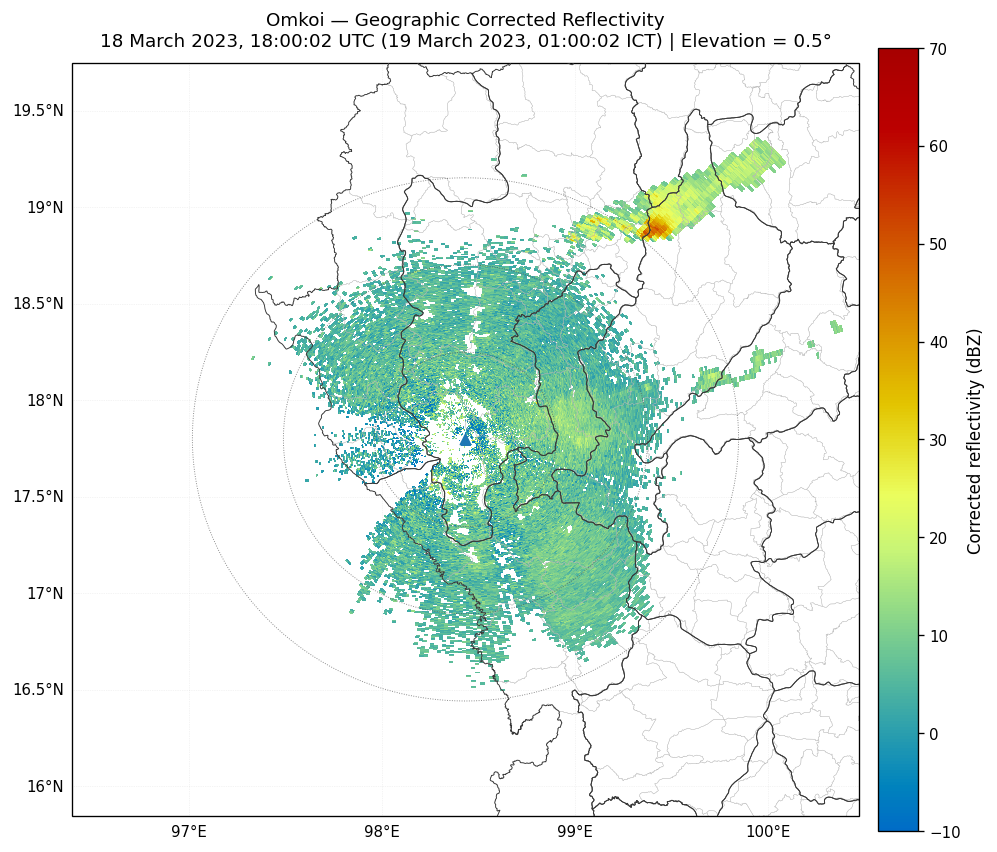

In [38]:
# CELL 38 — Geographic corrected reflectivity
F=FIGURE_DIR/'02_fig13_geographic_corrected_reflectivity.png'
plot_geographic_ppi(radar,corr_z,sweep=SWEEP,adm1=adm1,adm2=adm2,
                    title=f'{site_name} — Geographic Corrected Reflectivity\n{utc_time.strftime("%d %B %Y, %H:%M:%S UTC")} ({ict_time.strftime("%d %B %Y, %H:%M:%S ICT")}) | Elevation = {elev:.1f}°',
                    colorbar_label='Corrected reflectivity (dBZ)',cmap=CMAP_Z,vmin=Z_MIN,vmax=Z_MAX,
                    output_path=F,source_file=selected_filename,field=FIELD_Z_CORR,
                    processing='Py-ART gate lon/lat + ADM1 + simplified ADM2.',show_adm2=True)

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_fig14_geographic_dealiased_velocity.png


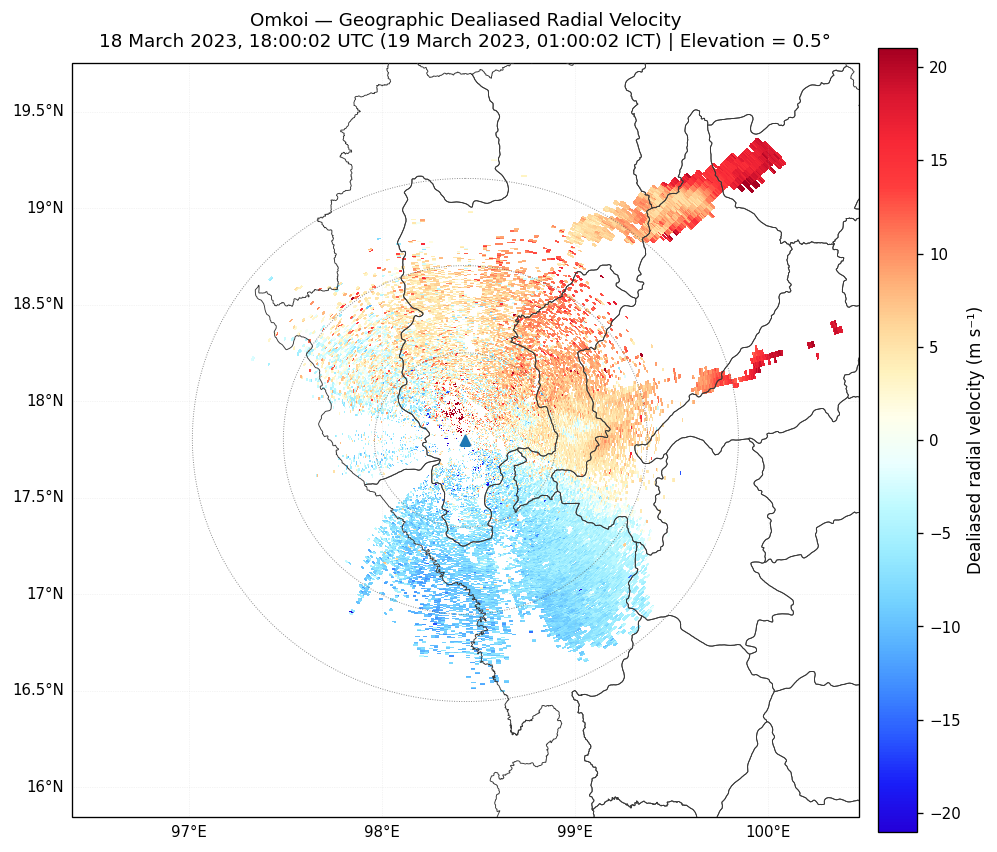

In [39]:
# CELL 39 — Geographic dealiased velocity
F=FIGURE_DIR/'02_fig14_geographic_dealiased_velocity.png'
plot_geographic_ppi(radar,dealiased_velocity,sweep=SWEEP,adm1=adm1,adm2=adm2,
                    title=f'{site_name} — Geographic Dealiased Radial Velocity\n{utc_time.strftime("%d %B %Y, %H:%M:%S UTC")} ({ict_time.strftime("%d %B %Y, %H:%M:%S ICT")}) | Elevation = {elev:.1f}°',
                    colorbar_label='Dealiased radial velocity (m s⁻¹)',cmap=CMAP_V,vmin=-vel_limit,vmax=vel_limit,
                    output_path=F,source_file=selected_filename,field=FIELD_VEL_DEALIASED,
                    processing='Region-based dealiased velocity + ADM1.',show_adm2=False)

# 19. One-hour evolution from 10 radar volumes

All time-series metrics below use **sweep 0** and are descriptive polar-domain diagnostics. Gate counts are not physical area.

In [40]:
# CELL 40 — Build one-hour summary
rows=[]
for i,fn in enumerate(RADAR_FILES,1):
    print(f'[{i:02d}/{len(RADAR_FILES)}] {fn}')
    r=read_radar_file(RADAR_DIR/fn); u,l=utc_and_ict(r)
    z=np.ma.asarray(r.get_field(SWEEP,FIELD_Z_CORR,copy=True)); v=np.ma.asarray(r.get_field(SWEEP,FIELD_VEL,copy=True)); s=np.ma.asarray(r.get_field(SWEEP,FIELD_SW,copy=True))
    zv=z.compressed(); zv=zv[np.isfinite(zv)]; vv=v.compressed(); vv=vv[np.isfinite(vv)]; sv=s.compressed(); sv=sv[np.isfinite(sv)]
    rows.append({'filename':fn,'time_UTC':u,'time_ICT':l,'elevation_deg':float(r.fixed_angle['data'][SWEEP]),
                 'valid_corrected_ZH_gates':int(zv.size),'max_corrected_ZH_dBZ':float(np.nanmax(zv)) if zv.size else np.nan,
                 'P95_corrected_ZH_dBZ':float(np.nanpercentile(zv,95)) if zv.size else np.nan,
                 'gate_count_ZH_ge_40':int((zv>=40).sum()),'gate_count_ZH_ge_50':int((zv>=50).sum()),
                 'max_abs_raw_velocity_ms':float(np.nanmax(np.abs(vv))) if vv.size else np.nan,
                 'P95_spectrum_width_ms':float(np.nanpercentile(sv,95)) if sv.size else np.nan})
volume_time_summary=pd.DataFrame(rows); display(volume_time_summary)
VOLUME_TIME_CSV=OUTPUT_CSV_DIR/'02_volume_time_summary.csv'; volume_time_summary.to_csv(VOLUME_TIME_CSV,index=False)

[01/10] 20230318180002.uf.gz
[02/10] 20230318180602.uf.gz
[03/10] 20230318181202.uf.gz
[04/10] 20230318181802.uf.gz
[05/10] 20230318182402.uf.gz
[06/10] 20230318183002.uf.gz
[07/10] 20230318183602.uf.gz
[08/10] 20230318184202.uf.gz
[09/10] 20230318184802.uf.gz
[10/10] 20230318185402.uf.gz


,filename,time_UTC,time_ICT,elevation_deg,valid_corrected_ZH_gates,max_corrected_ZH_dBZ,P95_corrected_ZH_dBZ,gate_count_ZH_ge_40,gate_count_ZH_ge_50,max_abs_raw_velocity_ms,P95_spectrum_width_ms
0,20230318180002.uf.gz,2023-03-18 18:00:02+00:00,2023-03-19 01:00:02+07:00,0.5,50595,51.5,16.0,71,4,16.7,4.59
1,20230318180602.uf.gz,2023-03-18 18:06:02+00:00,2023-03-19 01:06:02+07:00,0.5,50344,55.0,16.0,62,10,16.7,4.53
2,20230318181202.uf.gz,2023-03-18 18:12:02+00:00,2023-03-19 01:12:02+07:00,0.5,50219,57.0,16.0,36,5,16.7,4.53
3,20230318181802.uf.gz,2023-03-18 18:18:02+00:00,2023-03-19 01:18:02+07:00,0.5,49366,50.5,16.0,33,2,16.7,4.53
4,20230318182402.uf.gz,2023-03-18 18:24:02+00:00,2023-03-19 01:24:02+07:00,0.5,49108,48.5,16.0,24,0,16.7,4.59
5,20230318183002.uf.gz,2023-03-18 18:30:02+00:00,2023-03-19 01:30:02+07:00,0.5,48372,51.0,16.0,53,2,16.7,4.53
6,20230318183602.uf.gz,2023-03-18 18:36:02+00:00,2023-03-19 01:36:02+07:00,0.5,48107,48.5,16.0,31,0,16.7,4.53
7,20230318184202.uf.gz,2023-03-18 18:42:02+00:00,2023-03-19 01:42:02+07:00,0.5,47674,47.0,15.5,34,0,16.7,4.53
8,20230318184802.uf.gz,2023-03-18 18:48:02+00:00,2023-03-19 01:48:02+07:00,0.5,47107,45.5,15.0,14,0,16.7,4.46
9,20230318185402.uf.gz,2023-03-18 18:54:02+00:00,2023-03-19 01:54:02+07:00,0.5,46657,42.5,15.0,6,0,16.7,4.46


Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_fig15_reflectivity_time_series.png


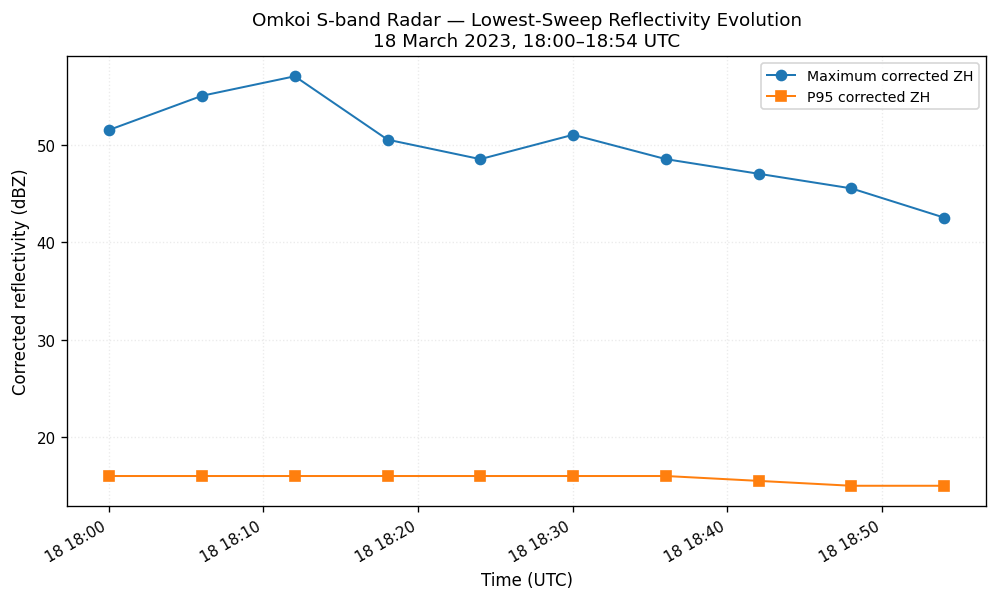

In [41]:
# CELL 41 — Reflectivity evolution
fig=plt.figure(figsize=(8.2,4.9)); ax=fig.add_subplot(111)
ax.plot(volume_time_summary['time_UTC'],volume_time_summary['max_corrected_ZH_dBZ'],marker='o',label='Maximum corrected ZH')
ax.plot(volume_time_summary['time_UTC'],volume_time_summary['P95_corrected_ZH_dBZ'],marker='s',label='P95 corrected ZH')
ax.set(xlabel='Time (UTC)',ylabel='Corrected reflectivity (dBZ)',
       title=f'{site_name} S-band Radar — Lowest-Sweep Reflectivity Evolution\n18 March 2023, 18:00–18:54 UTC')
ax.grid(alpha=0.25,linestyle=':'); ax.legend(); fig.autofmt_xdate()
F=FIGURE_DIR/'02_fig15_reflectivity_time_series.png'
save_figure(fig,F,field=FIELD_Z_CORR,sweep=SWEEP,elevation_deg=elev,processing='One-hour sweep-0 maximum and P95 corrected reflectivity.',dpi=300)
plt.show()

# 20. Export the 10 individual lowest-sweep reflectivity frames

Every frame uses the same field, scale, range and sweep. This prevents automatic rescaling from visually exaggerating changes.

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_time_sequence_20230318_180002UTC.png


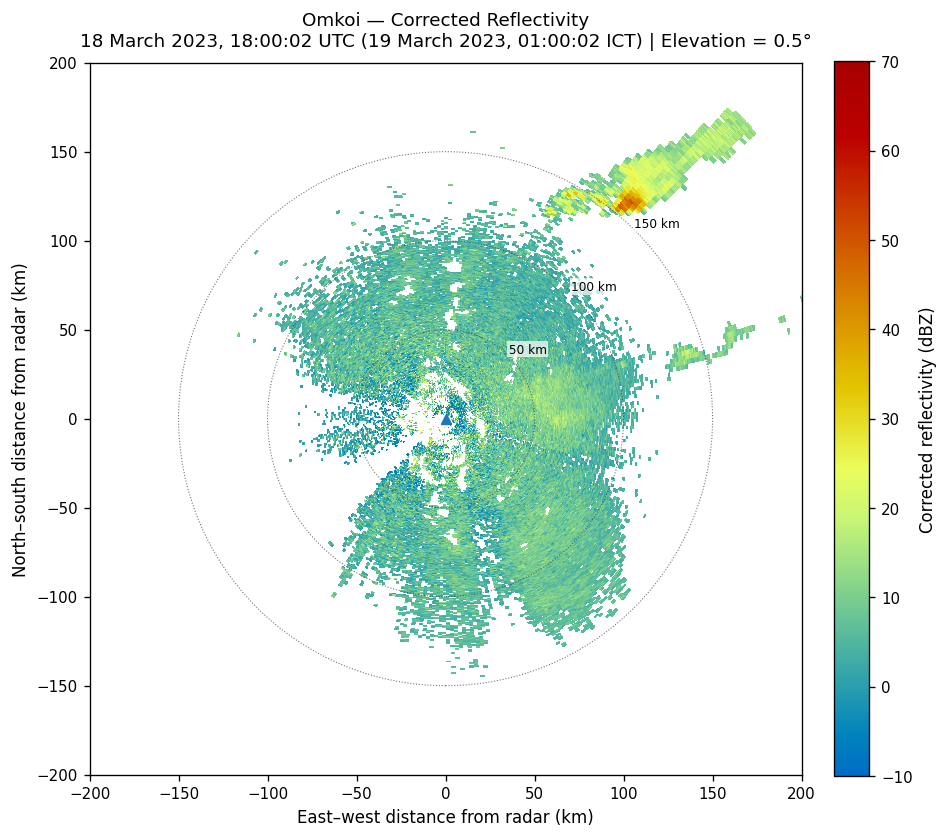

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_time_sequence_20230318_180602UTC.png


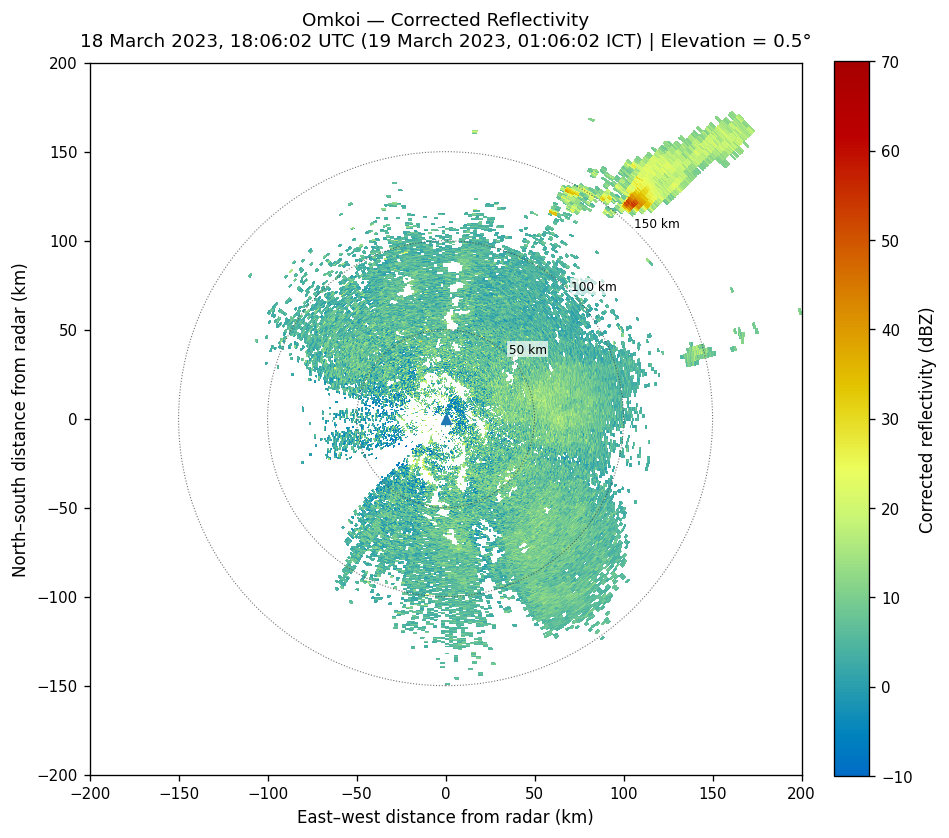

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_time_sequence_20230318_181202UTC.png


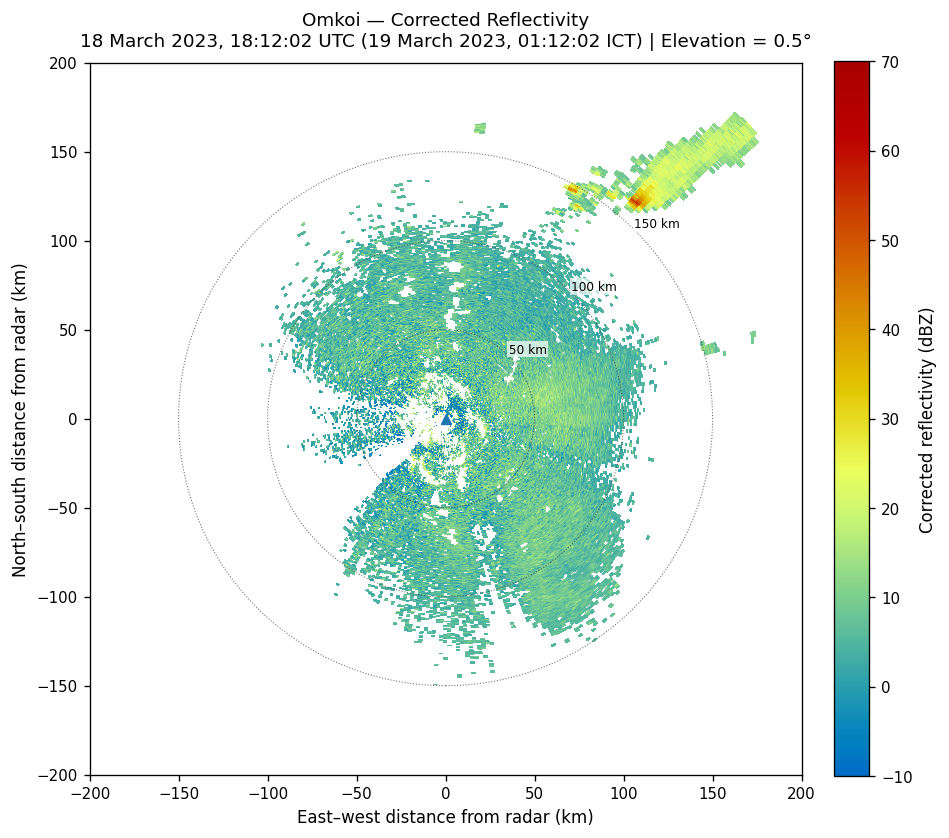

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_time_sequence_20230318_181802UTC.png


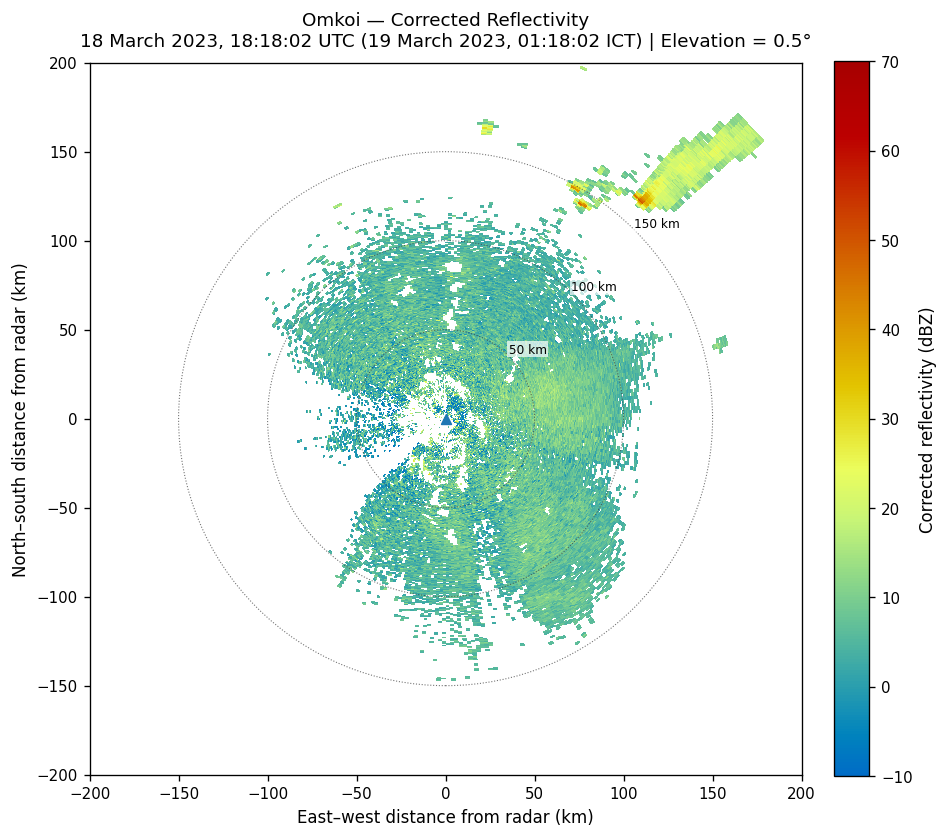

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_time_sequence_20230318_182402UTC.png


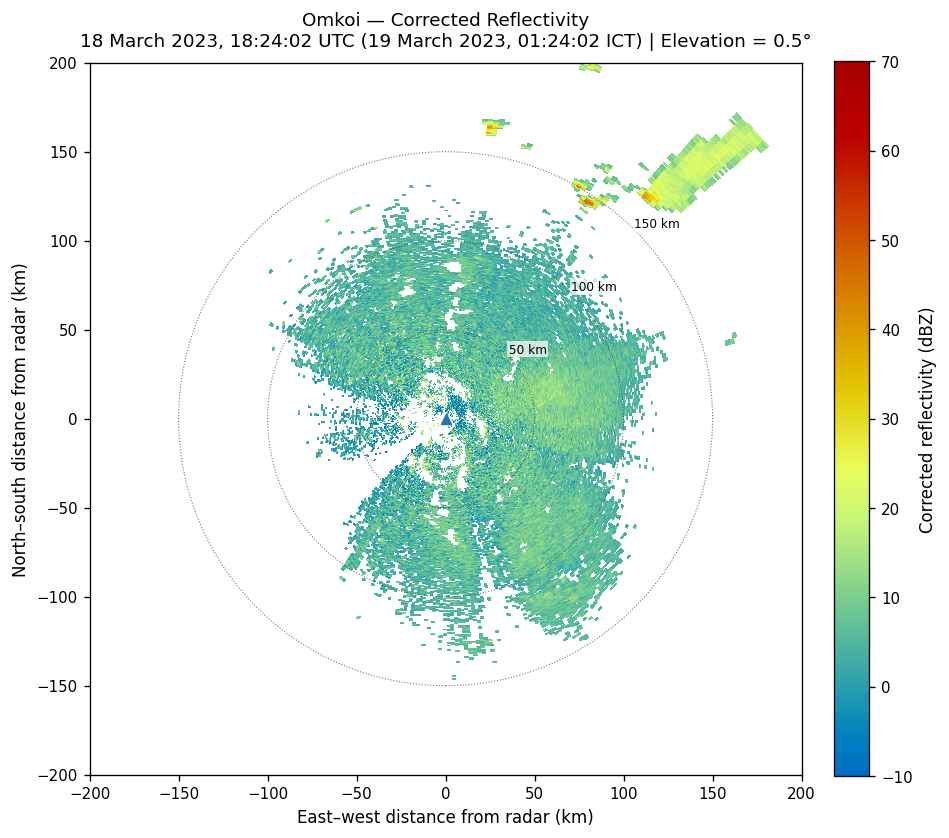

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_time_sequence_20230318_183002UTC.png


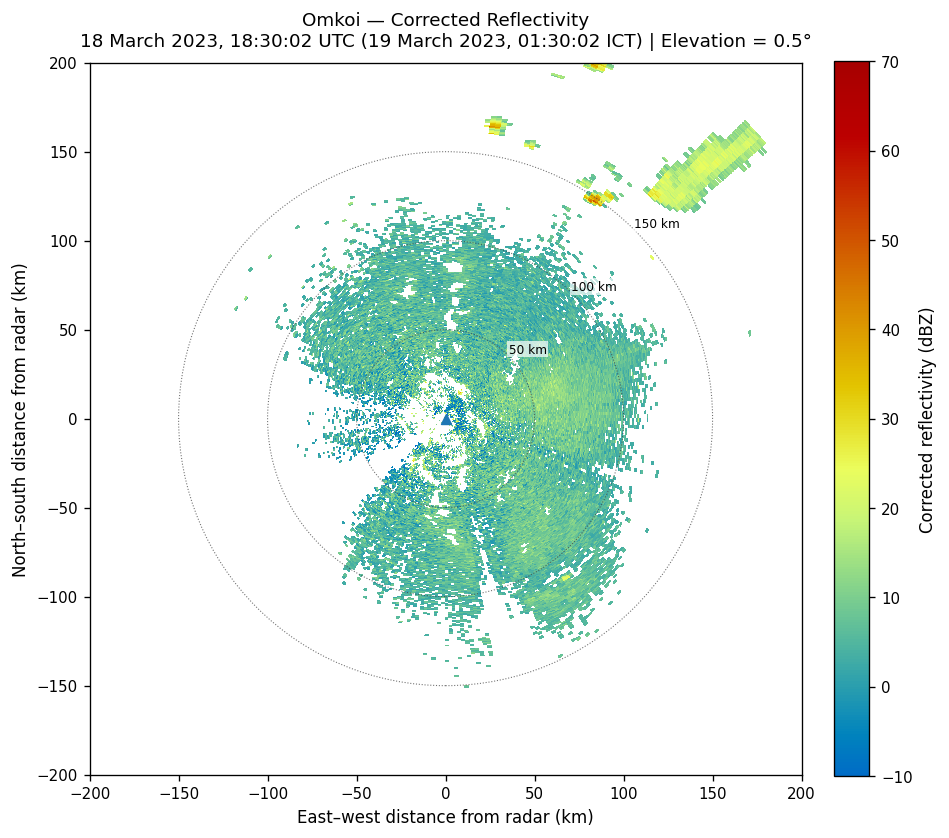

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_time_sequence_20230318_183602UTC.png


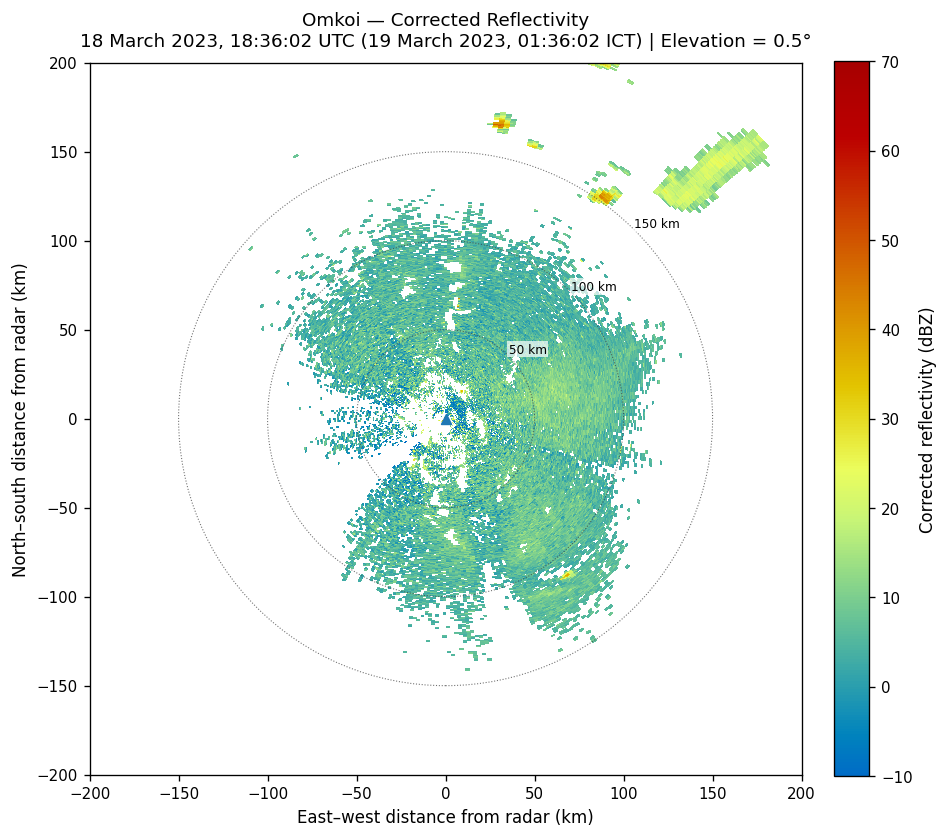

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_time_sequence_20230318_184202UTC.png


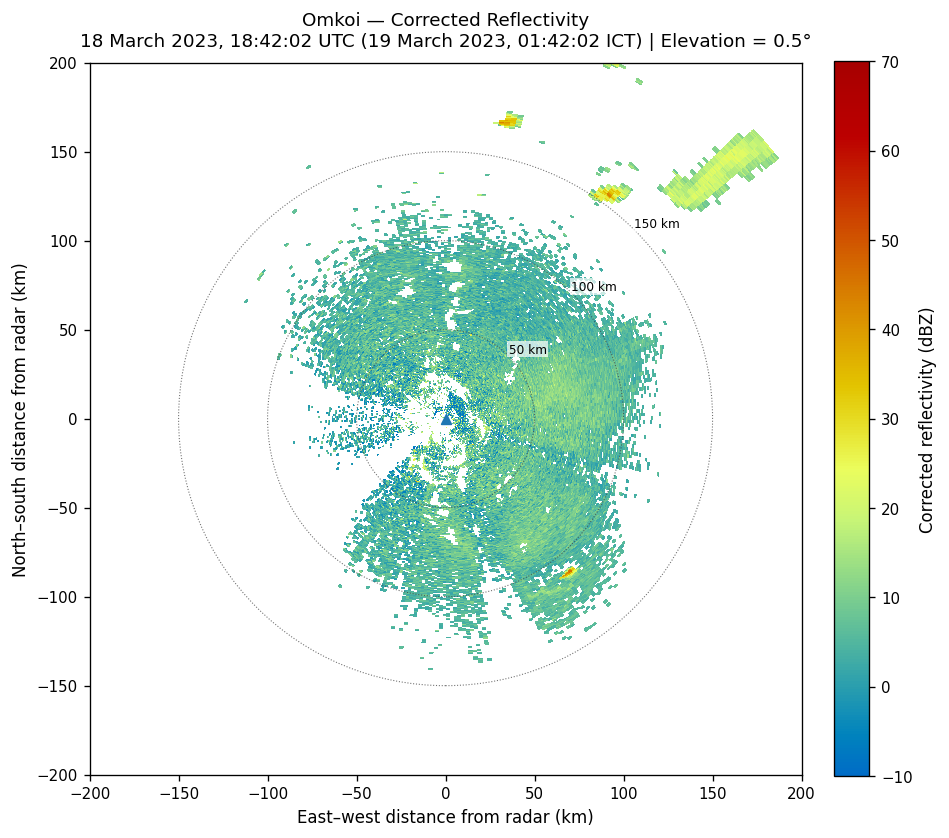

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_time_sequence_20230318_184802UTC.png


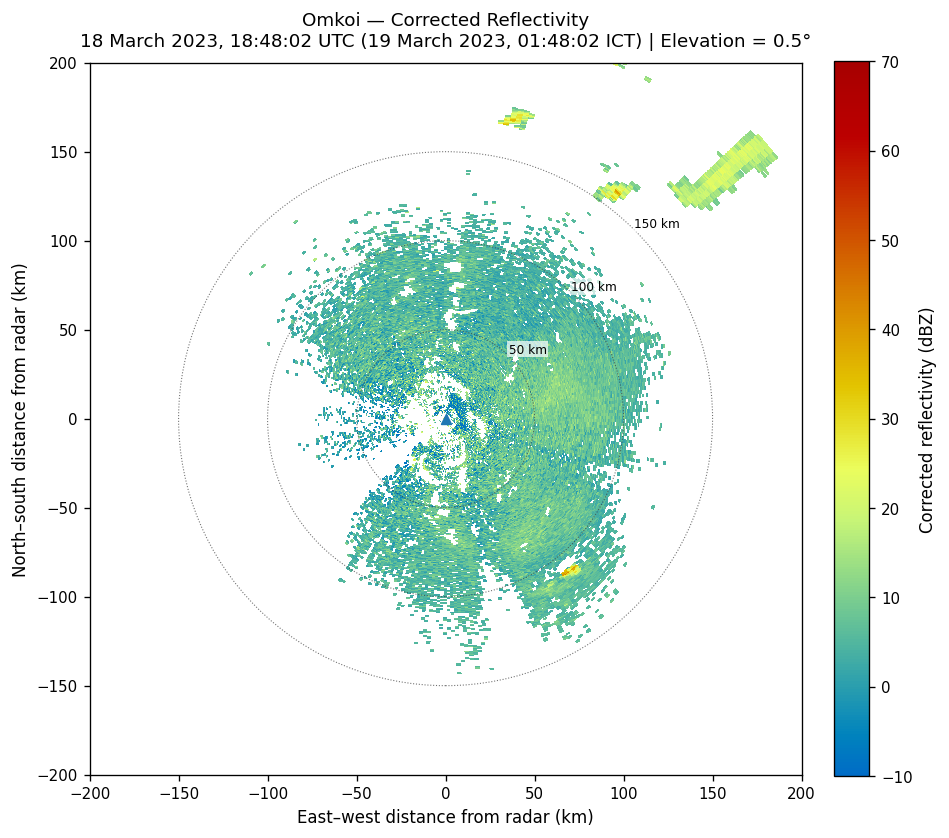

Saved: /content/drive/MyDrive/Teaching_DRRAA_WeatherRadar_GIS/04_figures/02/02_time_sequence_20230318_185402UTC.png


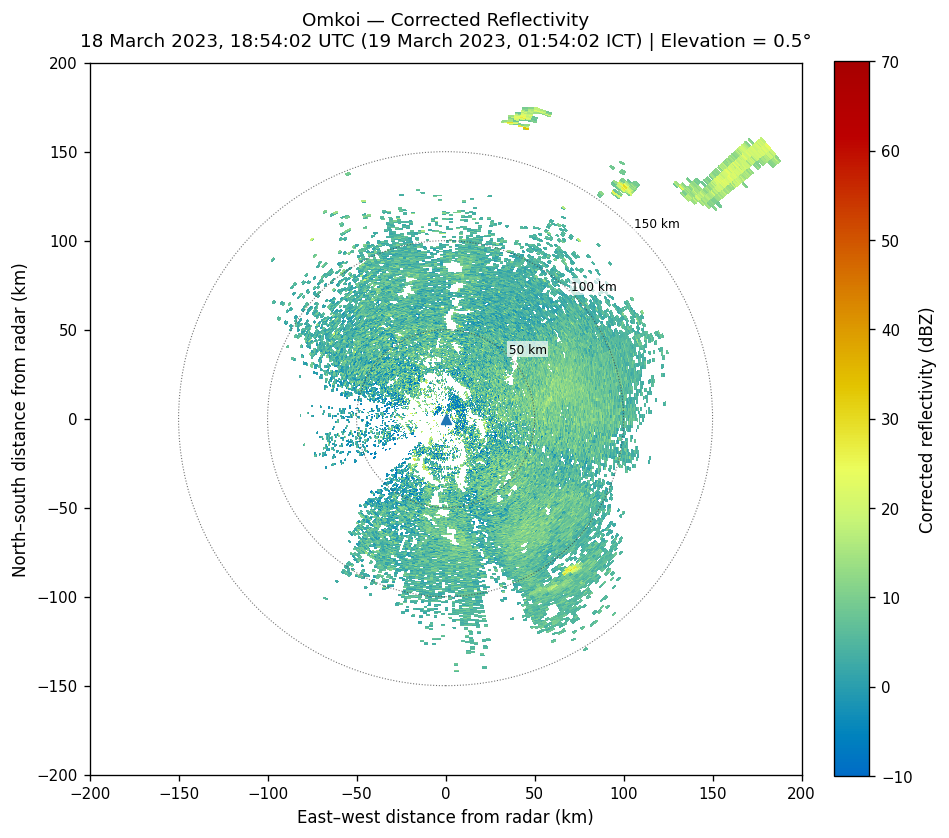

In [42]:
# CELL 42 — Consistent one-hour PPI sequence
for fn in RADAR_FILES:
    r=read_radar_file(RADAR_DIR/fn); u,l=utc_and_ict(r); el=float(r.fixed_angle['data'][SWEEP]); z=r.get_field(SWEEP,FIELD_Z_CORR,copy=True)
    F=FIGURE_DIR/f'02_time_sequence_{u.strftime("%Y%m%d_%H%M%S")}UTC.png'
    plot_native_ppi_array(r,z,sweep=SWEEP,
                          title=f'{site_name} — Corrected Reflectivity\n{u.strftime("%d %B %Y, %H:%M:%S UTC")} ({l.strftime("%d %B %Y, %H:%M:%S ICT")}) | Elevation = {el:.1f}°',
                          colorbar_label='Corrected reflectivity (dBZ)',cmap=CMAP_Z,vmin=Z_MIN,vmax=Z_MAX,
                          output_path=F,source_file=fn,field=FIELD_Z_CORR,
                          processing='One-hour PPI sequence; identical parameters.')

# 21. Conditional availability inside precipitation echoes

Instead of asking only “what fraction of the whole volume is masked?”, evaluate

\[
P(valid\ field\mid Z_H\ge threshold)
\]

This is especially important before deciding whether ZDR, \(\rho_{HV}\), \(\Phi_{DP}\) and \(K_{DP}\) can support later hail algorithms.

In [43]:
# CELL 43 — Conditional field availability
availability_fields=['corrected_differential_reflectivity','cross_correlation_ratio','differential_phase','specific_differential_phase',FIELD_VEL,FIELD_SW]
z=np.ma.asarray(radar.fields[FIELD_Z_CORR]['data']); zv=z.filled(np.nan); zvalid=(~np.ma.getmaskarray(z)&np.isfinite(zv))
rows=[]
for fname in availability_fields:
    if fname not in radar.fields: continue
    a=np.ma.asarray(radar.fields[fname]['data']); av=a.filled(np.nan); valid=(~np.ma.getmaskarray(a)&np.isfinite(av))
    for th in ZH_THRESHOLDS:
        denmask=zvalid&(zv>=th); den=int(denmask.sum()); num=int((denmask&valid).sum())
        rows.append({'field':fname,'ZH_threshold_dBZ':th,'precipitation_gate_count':den,
                     'field_valid_gate_count':num,'conditional_valid_fraction':num/den if den else np.nan})
conditional_availability=pd.DataFrame(rows); display(conditional_availability)
AVAILABILITY_CSV=OUTPUT_CSV_DIR/'02_field_conditional_availability.csv'; conditional_availability.to_csv(AVAILABILITY_CSV,index=False)

,field,ZH_threshold_dBZ,precipitation_gate_count,field_valid_gate_count,conditional_valid_fraction
0,corrected_differential_reflectivity,10.0,43075,38962,0.904515
1,corrected_differential_reflectivity,20.0,11949,11452,0.958407
2,corrected_differential_reflectivity,30.0,9714,9674,0.995882
3,corrected_differential_reflectivity,40.0,176,174,0.988636
4,corrected_differential_reflectivity,50.0,4,4,1.000000
5,cross_correlation_ratio,10.0,43075,42806,0.993755
6,cross_correlation_ratio,20.0,11949,11944,0.999582
7,cross_correlation_ratio,30.0,9714,9714,1.000000
8,cross_correlation_ratio,40.0,176,176,1.000000
9,cross_correlation_ratio,50.0,4,4,1.000000


In [44]:
# CELL 44 — Availability matrix
availability_matrix=conditional_availability.pivot(index='field',columns='ZH_threshold_dBZ',values='conditional_valid_fraction')
availability_matrix.columns=[f'ZH_ge_{int(c)}dBZ' for c in availability_matrix.columns]
display(availability_matrix)

,ZH_ge_10dBZ,ZH_ge_20dBZ,ZH_ge_30dBZ,ZH_ge_40dBZ,ZH_ge_50dBZ
field,,,,,
corrected_differential_reflectivity,0.904515,0.958407,0.995882,0.988636,1.0
cross_correlation_ratio,0.993755,0.999582,1.000000,1.000000,1.0
differential_phase,0.074521,0.061595,0.017603,0.301136,1.0
specific_differential_phase,0.074521,0.061595,0.017603,0.301136,1.0
spectrum_width,0.595821,0.185204,0.078341,0.346591,1.0
velocity,0.786814,0.262198,0.093473,0.386364,1.0


## Hail-track decision rule

If dual-polarization variables are still sparse within strong echoes, advanced HDR/HSDA work should remain **conditional**. MESH based on reflectivity volume and thermal levels can remain the core hail pathway if data support it.

# 22. Export figure manifest and output inventory

In [45]:
# CELL 45 — Figure manifest
figure_manifest=pd.DataFrame(FIGURE_RECORDS)
FIGURE_MANIFEST_CSV=OUTPUT_CSV_DIR/'02_figure_manifest.csv'; figure_manifest.to_csv(FIGURE_MANIFEST_CSV,index=False)
display(figure_manifest)

,figure_name,figure_path,source_file,field,processing,dpi,sweep,elevation_deg,time_UTC,time_ICT,vmin,vmax,colormap
0,02_fig01_scan_elevation_angles.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318180002.uf.gz,fixed_angle,UF/Py-ART sweep metadata.,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,02_fig02_beam_height_vs_range.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318180002.uf.gz,beam_geometry,4/3 effective Earth radius; height MSL.,300,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,02_fig03_raw_reflectivity_20230318_180002UTC_E...,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318180002.uf.gz,reflectivity,Native UF reflectivity; no additional Notebook...,300,0.0,0.500000,2023-03-18 18:00:02+00:00,2023-03-19 01:00:02+07:00,-10.000000,70.000000,HomeyerRainbow
3,02_fig04_corrected_reflectivity_20230318_18000...,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318180002.uf.gz,corrected_reflectivity,Corrected reflectivity supplied in source UF d...,300,0.0,0.500000,2023-03-18 18:00:02+00:00,2023-03-19 01:00:02+07:00,-10.000000,70.000000,HomeyerRainbow
4,02_fig05_reflectivity_difference.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318180002.uf.gz,corrected_minus_raw_reflectivity,Difference on common valid gates only.,300,0.0,0.500000,2023-03-18 18:00:02+00:00,2023-03-19 01:00:02+07:00,-20.000000,20.000000,RdBu_r
5,02_fig06_reflectivity_difference_distribution.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318180002.uf.gz,corrected_minus_raw_reflectivity,Common-valid-gate distribution.,300,0.0,0.500000,2023-03-18 18:00:02+00:00,2023-03-19 01:00:02+07:00,NaN,NaN,NaN
6,02_fig07_raw_vs_corrected_reflectivity.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318180002.uf.gz,reflectivity;corrected_reflectivity,Reproducible random sample of common valid gates.,300,0.0,0.500000,2023-03-18 18:00:02+00:00,2023-03-19 01:00:02+07:00,NaN,NaN,NaN
7,02_fig08_raw_velocity.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318180002.uf.gz,velocity,Native radial velocity before dealiasing.,300,0.0,0.500000,2023-03-18 18:00:02+00:00,2023-03-19 01:00:02+07:00,-16.700001,16.700001,BuDRd18
8,02_fig09_dealiased_velocity.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318180002.uf.gz,velocity_dealiased,Py-ART region-based dealiasing; ZHcorr >= 5.0 ...,300,0.0,0.500000,2023-03-18 18:00:02+00:00,2023-03-19 01:00:02+07:00,-21.000000,21.000000,BuDRd18
9,02_fig10_dealiased_minus_raw_velocity.png,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,20230318180002.uf.gz,velocity_dealiased_minus_raw,Difference on common valid velocity gates.,300,0.0,0.500000,2023-03-18 18:00:02+00:00,2023-03-19 01:00:02+07:00,-33.400002,33.400002,RdBu_r


In [46]:
# CELL 46 — Output inventory
expected=[SWEEP_TABLE_CSV,BEAM_TABLE_CSV,SAMPLING_CSV,DELTA_STATS_CSV,NYQUIST_CSV,DEALIAS_CSV,
          MULTI_ELEVATION_CSV,VOLUME_TIME_CSV,AVAILABILITY_CSV,FIGURE_MANIFEST_CSV]
output_inventory=pd.DataFrame({'path':[str(p) for p in expected],'exists':[Path(p).exists() for p in expected]})
display(output_inventory)

,path,exists
0,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
1,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
2,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
3,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
4,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
5,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
6,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
7,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
8,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True
9,/content/drive/MyDrive/Teaching_DRRAA_WeatherR...,True


# 23. Exercises

### CORE
1. เปรียบเทียบ beam height ของ 0.5° ที่ 50, 100, 150 และ 200 km
2. เปรียบเทียบ raw/corrected/difference reflectivity และอธิบายโดยไม่เรียก corrected field ว่า truth
3. อธิบายความหมายของ \(V_N=16.7\;m\,s^{-1}\)
4. เปรียบเทียบ raw และ dealiased velocity
5. เปรียบเทียบ spectrum-width distribution ทั้งหมดกับกรณี corrected ZH ≥ 10 dBZ
6. เปรียบเทียบ PPI ที่ 0.5° และ 5.2° โดยใช้ beam geometry

### ADVANCED / MSc
7. ทดลอง `DEALIAS_Z_MIN_DBZ = 0, 5, 10` แล้วประเมิน spatial continuity และ artifact
8. ใช้ cross-beam spacing อธิบายว่าเหตุใด 0.5-km Cartesian grid อาจ oversample ข้อมูลระยะไกล
9. ใช้ conditional field availability ตัดสินว่า polarimetric hail retrieval ใดควรเป็น CORE หรือ CONDITIONAL
10. เขียน caption ระดับ conference/journal สำหรับ geographic PPI โดยระบุ site, UTC/ICT, elevation, field, unit, GIS boundaries และ processing

# 24. Scientific interpretation checklist

For every radar figure ask:

```text
What is observed?
What is processed?
What is inferred?
What cannot yet be concluded?
```

Example:

```text
Observed: radar reflectivity echoes
Processed: corrected reflectivity supplied in the UF product
Can infer: spatial distribution of intense radar echo
Cannot yet conclude: surface rainfall amount or hail occurrence
```

# 25. Final readiness check

In [47]:
# CELL 47 — Notebook 02 readiness
checks=[]
def add(item,passed,note=''): checks.append({'item':item,'status':'PASS' if passed else 'FAIL','note':note})
add('Notebook 01 dataset readiness',bool(SETUP_STATUS.get('ready',False)))
add('Selected radar readable',radar is not None)
add('Raw reflectivity available',FIELD_Z_RAW in radar.fields)
add('Corrected reflectivity available',FIELD_Z_CORR in radar.fields)
add('Velocity available',FIELD_VEL in radar.fields)
add('Spectrum width available',FIELD_SW in radar.fields)
add('Nyquist velocity available',np.isfinite(nyquist))
add('Dealiased velocity created',FIELD_VEL_DEALIASED in radar.fields)
add('ADM1 loaded',len(adm1)>0); add('ADM2 loaded',len(adm2)>0)
add('Common reflectivity comparison available',delta_common.size>0)
add('One-hour summary has 10 volumes',len(volume_time_summary)==10)
add('Conditional field availability exported',AVAILABILITY_CSV.exists())
add('Figure manifest exported',FIGURE_MANIFEST_CSV.exists())
readiness=pd.DataFrame(checks); display(readiness)
READY=bool((readiness.status=='PASS').all())
READINESS_CSV=OUTPUT_CSV_DIR/'02_readiness_check.csv'; readiness.to_csv(READINESS_CSV,index=False)
print('\nNOTEBOOK 02 READY FOR CARTESIAN / CAPPI ANALYSIS' if READY else '\nNOTEBOOK 02 REQUIRES REVIEW')

,item,status,note
0,Notebook 01 dataset readiness,PASS,
1,Selected radar readable,PASS,
2,Raw reflectivity available,PASS,
3,Corrected reflectivity available,PASS,
4,Velocity available,PASS,
5,Spectrum width available,PASS,
6,Nyquist velocity available,PASS,
7,Dealiased velocity created,PASS,
8,ADM1 loaded,PASS,
9,ADM2 loaded,PASS,



NOTEBOOK 02 READY FOR CARTESIAN / CAPPI ANALYSIS


# Key messages

1. **PPI is a conical radar observation, not a constant-altitude map.**
2. Beam height increases with range and elevation.
3. The 4/3-Earth model is an approximation.
4. 500-m gate spacing does not imply 500-m resolution in all directions.
5. Raw and corrected reflectivity should be compared on common gates.
6. Corrected reflectivity is processed data, not independent truth.
7. Radial velocity is only the beam-parallel component.
8. Nyquist velocity defines the unambiguous Doppler interval.
9. Dealiasing must preserve the raw field and be diagnosed after correction.
10. Spectrum width is not a direct turbulence measurement.
11. Multi-elevation PPIs provide vertical context but are not cross-sections.
12. Geographic PPI remains a PPI after conversion to longitude/latitude.
13. Polar gate count is not physical storm area.
14. Consistent time-sequence figures require fixed scale, field, sweep and domain.
15. Conditional field availability is more informative than overall masked fraction for planning polarimetric retrievals.
16. Notebook 03 can now proceed to Cartesian gridding, CAPPI, CRS and GIS integration.

# Expected outputs

```text
03_output/csv/
├── 02_selected_volume_scan_strategy.csv
├── 02_beam_height_lowest_sweep.csv
├── 02_polar_sampling_geometry.csv
├── 02_reflectivity_common_mask_stats.csv
├── 02_scan_nyquist_velocity.csv
├── 02_velocity_dealiasing_summary.csv
├── 02_multi_elevation_reflectivity_summary.csv
├── 02_volume_time_summary.csv
├── 02_field_conditional_availability.csv
├── 02_figure_manifest.csv
└── 02_readiness_check.csv

04_figures/02/
├── scan-strategy figure
├── beam-height figure
├── raw/corrected/difference reflectivity figures
├── correction distribution and scatter diagnostic
├── raw/dealiased/difference velocity figures
├── spectrum-width figures
├── selected-elevation reflectivity figures
├── geographic reflectivity and velocity figures
├── one-hour reflectivity time series
└── 10 consistently formatted PPI sequence frames
```

When the final message is:

```text
NOTEBOOK 02 READY FOR CARTESIAN / CAPPI ANALYSIS
```

continue to **Notebook 03 — Cartesian Grid, CAPPI, CRS and GIS Integration**.